# Exercises

## Exercise 1 - simulating place cells
---
Use the code we build to simulate place cells in the lesson.

A - Explore what happens when you change the binning in the definition of the firing rate maps (`space_bins`). Make it coarser or broader. 


B - In the spike train simulations, we add some "baseline" noise, not place-related to the firing. Which variable determines the noise level? Try to experiment with that variable and see what happens to the firing rate maps. What is the best approach to firing rate maps when the noise is high.


C - We could use other approaches to firing rate maps: for example make the binning very small (down to 1 cm, which is the resolution of our "video" data, and then applying a gaussian smoother. Scipy has a Gaussian smoother at `scipy.stats.gaussian_kde`. Read the documentation for that function and apply it to the data to define the smoothed firing rate maps. Again, change the noise levels and see how the smoother changes. 

D - When analyzing place fields, two important quantities are the place field center and the place field width. The place field center may be defined in many ways, but one is to compute the "center of mass" of the spikes according to the equation 

$$ 
c_{pf} = \frac{1}{N_{spikes}} \sum_{i} L_i 
$$ 

where the sum on $i$ runs on all spikes emitted by a cell and $L_i$ is the location at which the i-th spike was emitted. Calculate this for each cell. Compare with the "true" place field centers from the simulations (which variables are we talking about?) 


In [1]:
import os

os.chdir("C:/Users/larsb/Cognitive_neuroscience_RU/neuro-analysis-nongit/single-cell-analysis-master/01-tuning-curves")

import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from tqdm import tqdm
import seaborn as sns
import pickle
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [2]:
#import data
with open('data/psth_data.pickle', 'rb') as handle:
    data = pickle.load(handle)

spike_times = data['spike_times']
stim_onsets = data['stim_onsets']
stim_type = data['stim_type']
stim_duration = data['stim_duration']

print(stim_duration)
print(stim_type)

2
[2 2 2 1 2 1 2 1 2 2 1 2 1 2 2 2 1 1 1 2 1 1 2 2 1 1 1 1 2 1 2 1 2 1 2 2 1
 2 1 2 1 1 2 2 2 1 1 1 2 2 2 2 2 1 1 2 1 1 1 1 1 2 1 1 2 2 1 1 2 1 2 2 2 1
 1 2 1 2 1 2 1 1 2 2 2 2 1 2 2 1 1 2 1 1 1 1 2 2 1 2]


C:\Users\larsb\AppData\Local\Temp\ipykernel_23356\3650356877.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(handle)


In [3]:
# All copied from the tuning-curves.ipynb file
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells)

bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    x = np.concatenate((x, stop1, run1, stop2, run2))
t = np.arange(len(x))/fps

sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

def plot_unit(i):
    plt.figure(figsize=(10,5))
    plt.plot(t, x)
    plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    plt.xlabel('Time (s)')
    plt.ylabel('position on track (cm)')
    
interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0))

spike_positions = [np.interp(s, t, x) for s in spikes]

100%|██████████| 100/100 [00:59<00:00,  1.69it/s]


interactive(children=(IntSlider(value=0, description='i', max=99), Output()), _dom_classes=('widget-interact',…

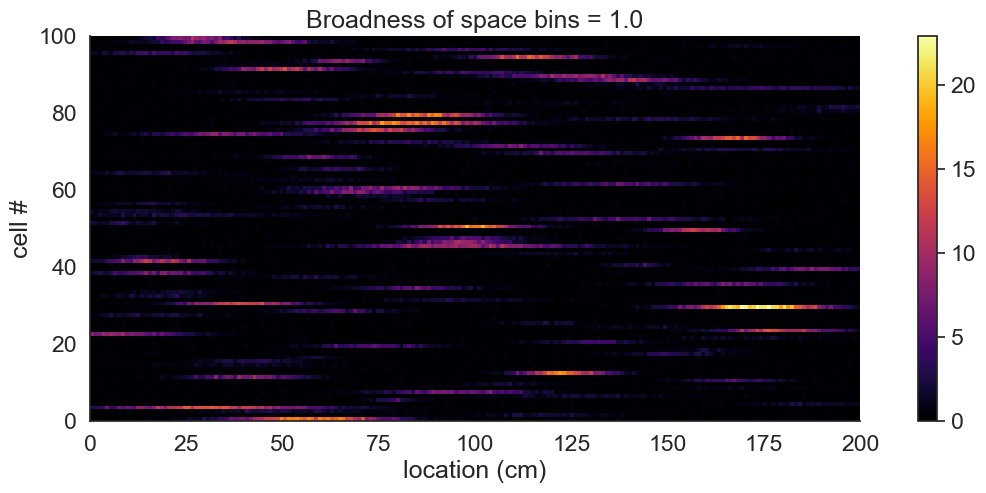

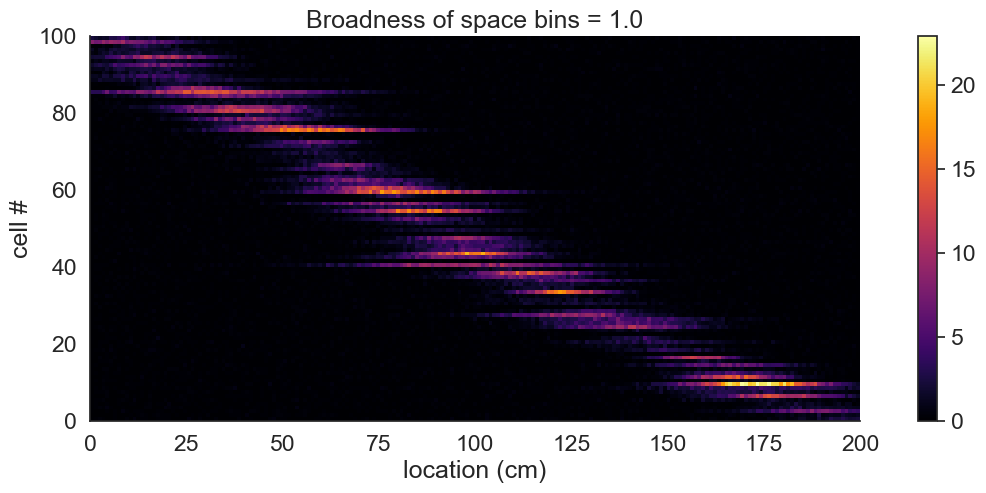

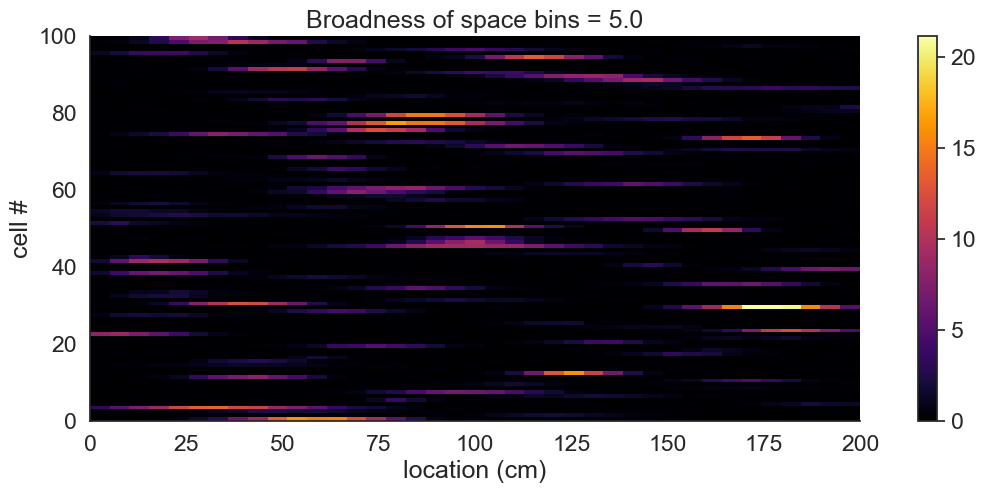

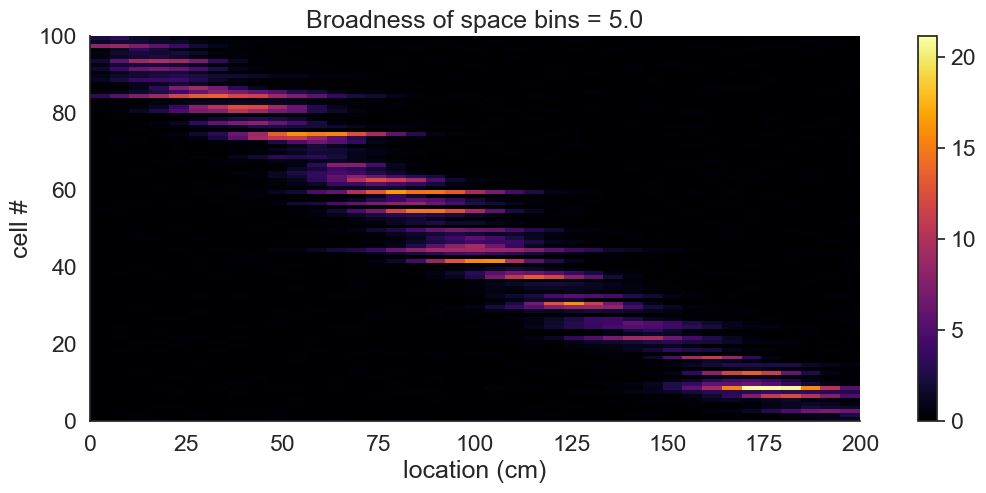

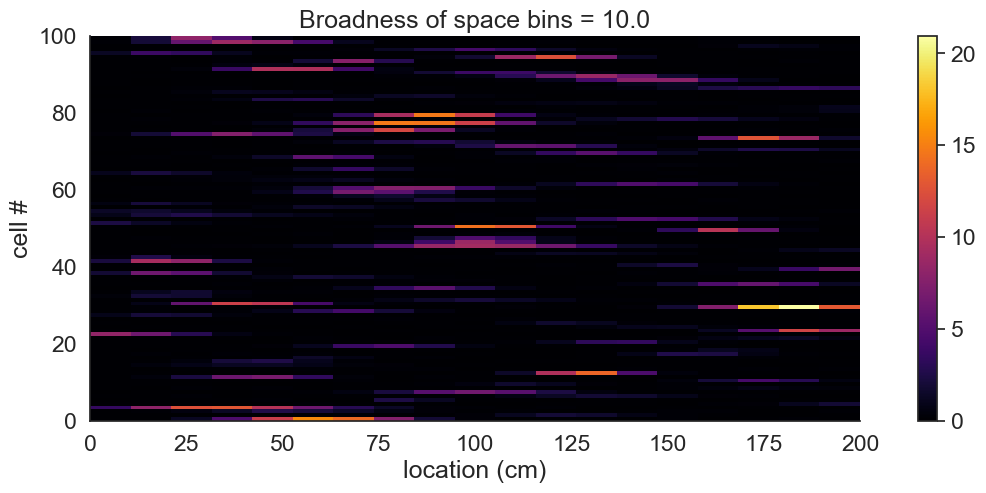

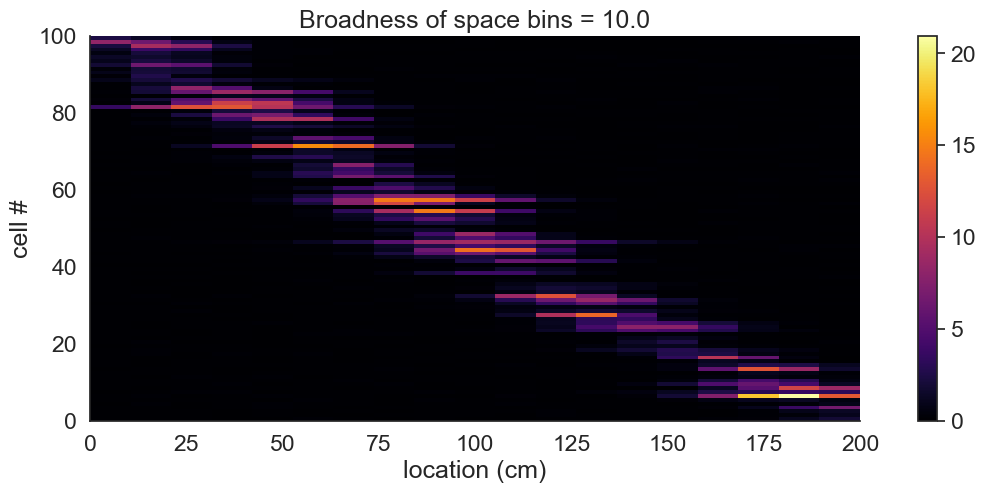

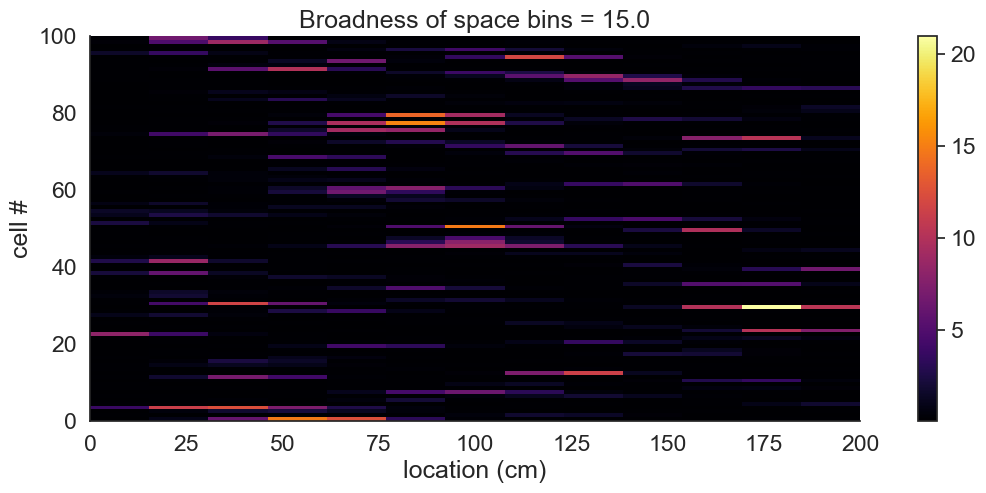

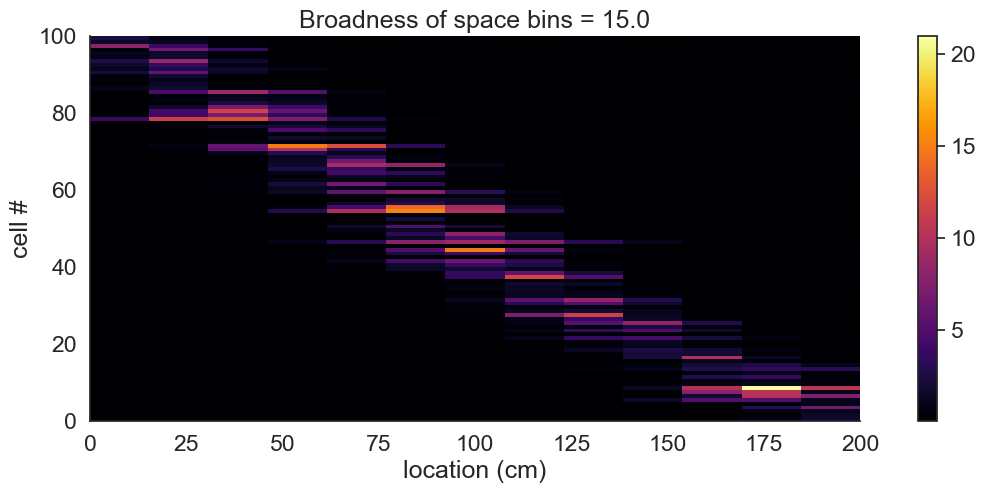

In [ ]:
# Copied form the tuning-curves.ipynb file, only added a for loop that loops over different
# broadness for space bins
broadness = [1. , 5. , 10. , 15.]

for b in broadness:
    space_bins = np.arange(0., 200., b)

# we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_maps = spikes_hist / occupancy 

    plt.figure(figsize=(15,5))
    plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Broadness of space bins = {b}")

    plt.figure(figsize=(15,5))
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Broadness of space bins = {b}")

# As you can see in the figures a smaller broadness makes the spatial resolution of the 
# firing rate maps better. Because of this: firing_rate_maps = spikes_hist / occupancy
# smaller bins means less spikes per bin and less occupancy time whereby one extra or less
# spike has more effect on the plots than with more broad space bins

100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


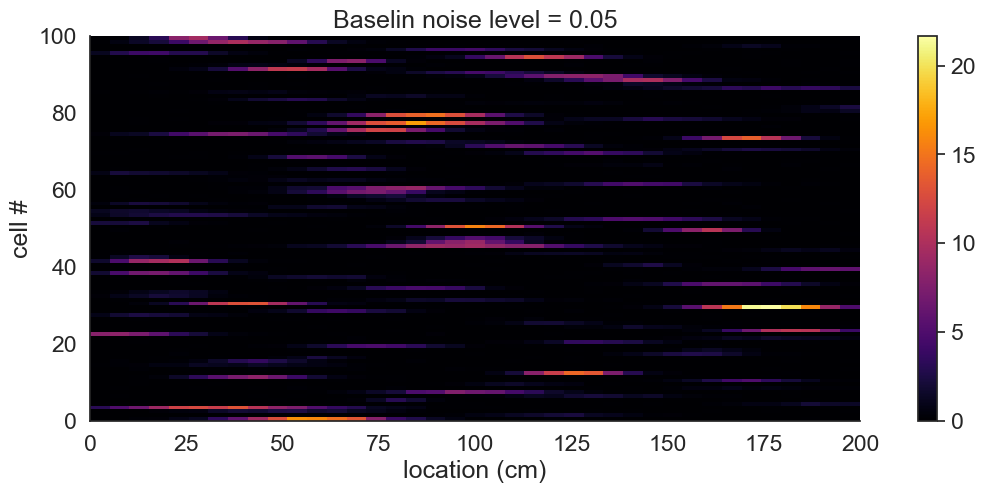

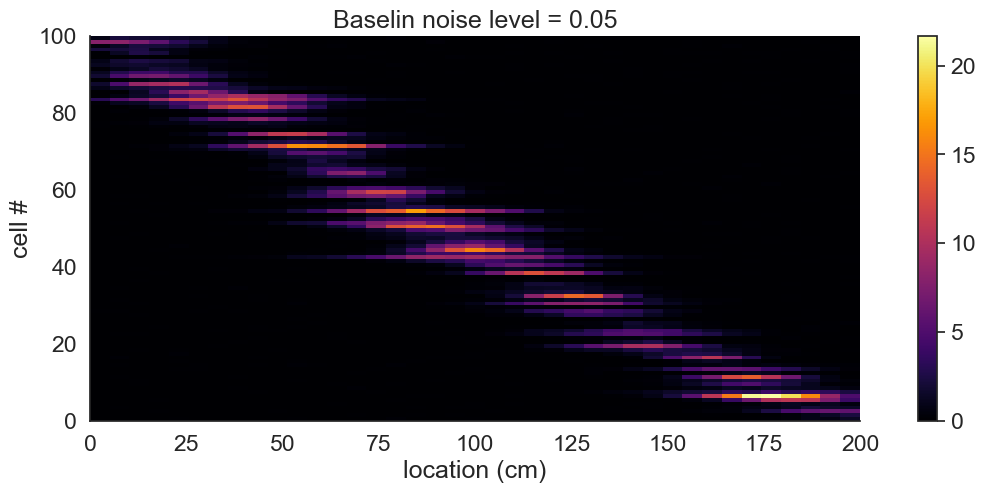

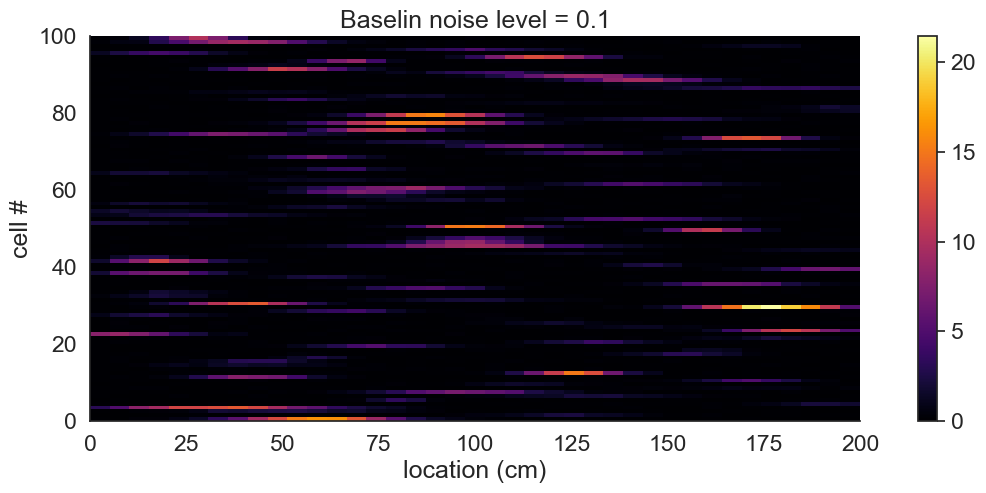

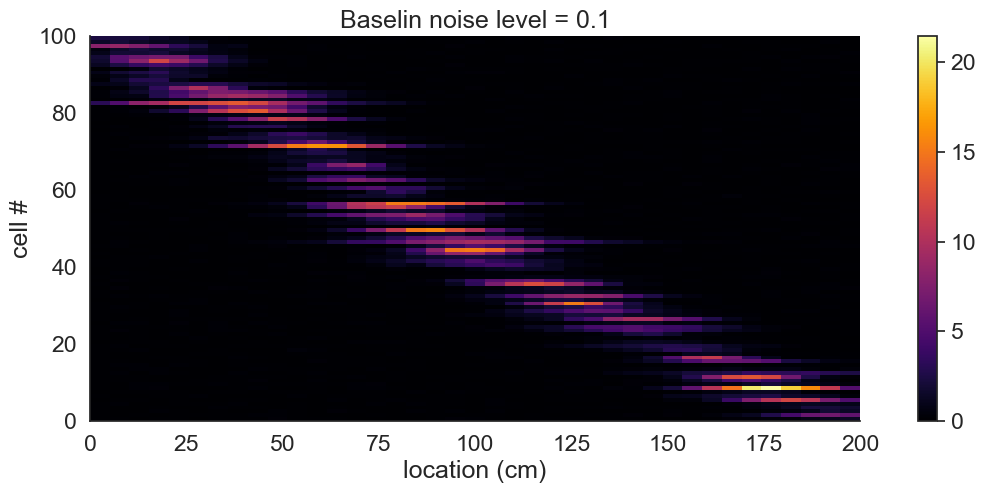

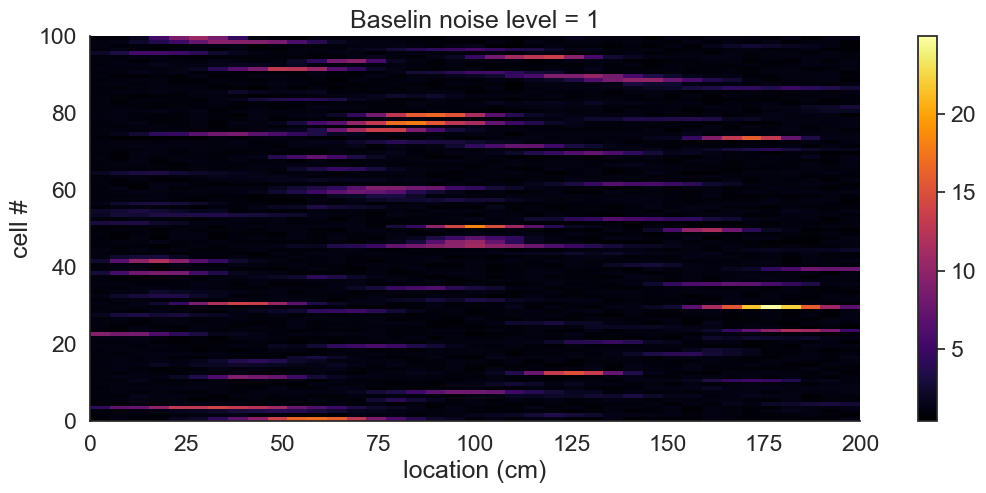

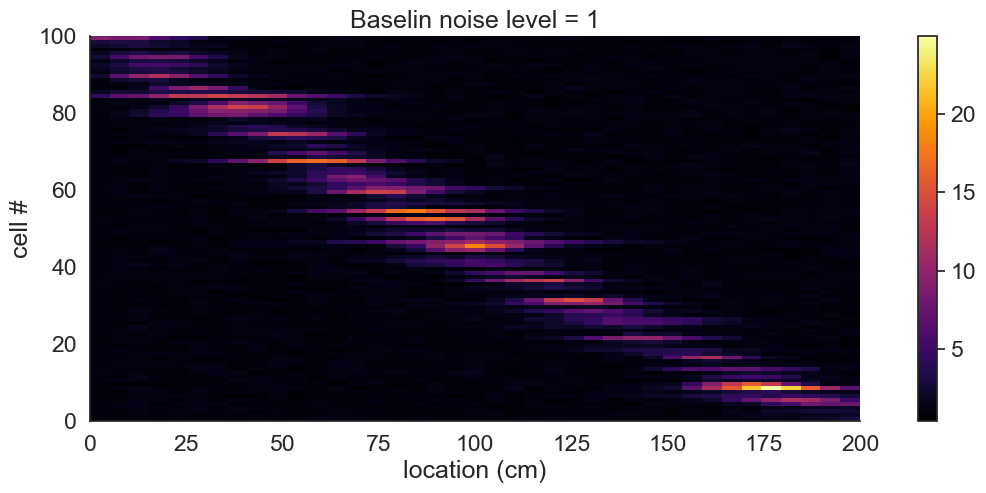

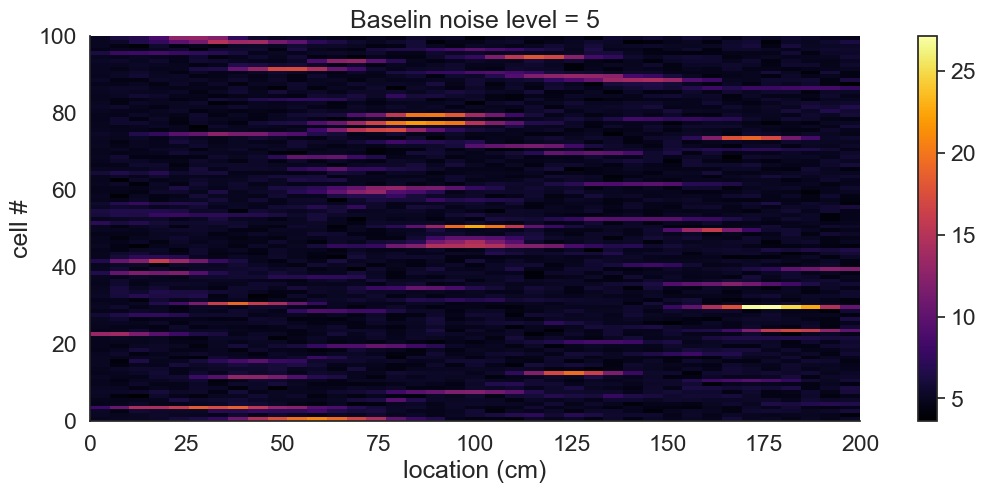

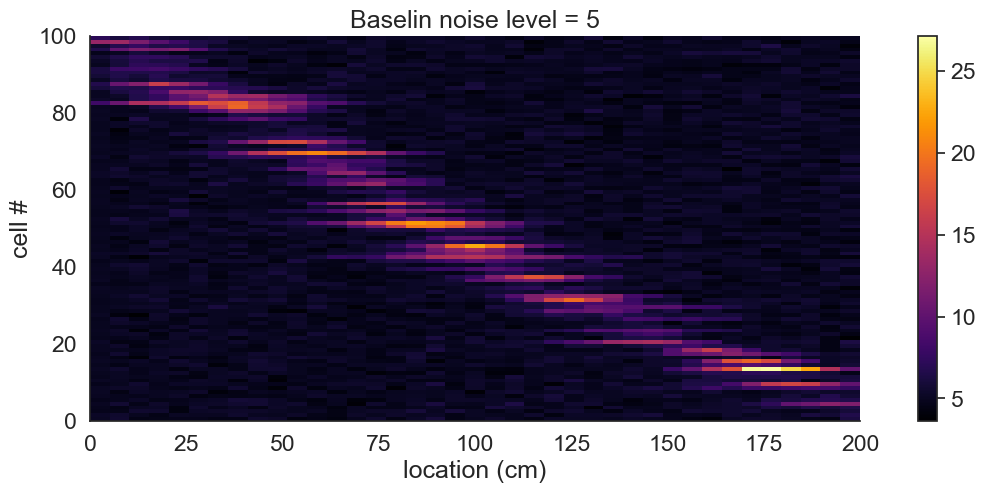

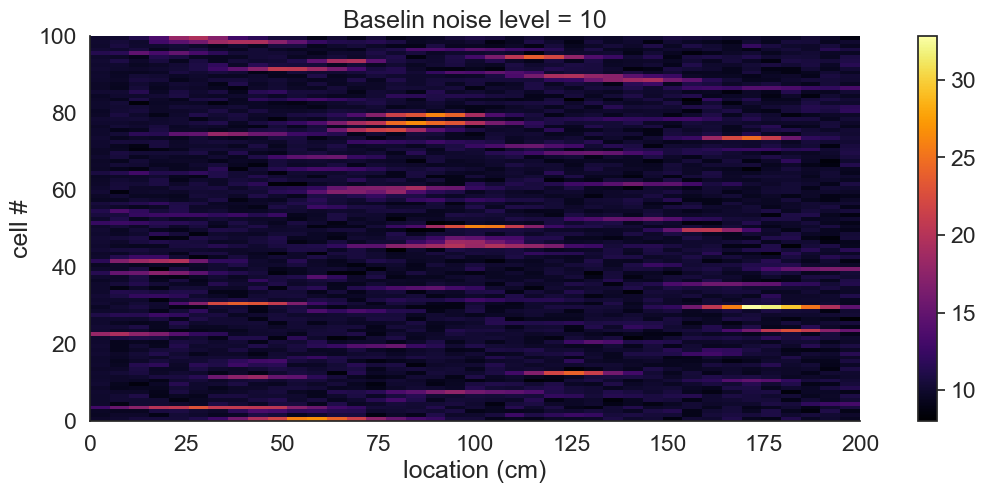

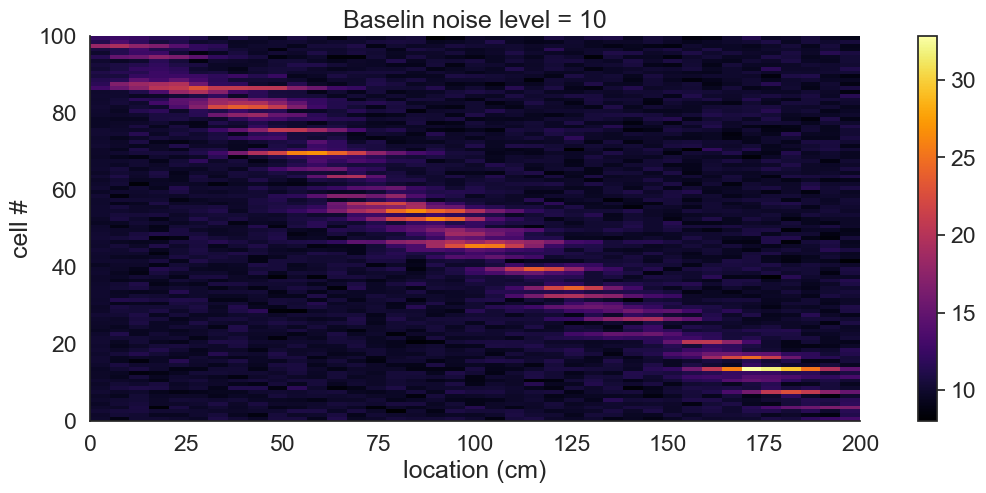

In [ ]:
#Excersize B
noise_levels = [0.05, 0.1, 1, 5, 10]
for noise_firing_rate in noise_levels:
    spikes = []
    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)

    spike_positions = [np.interp(s, t, x) for s in spikes]

    space_bins = np.arange(0., 200., 5.)

# we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_maps = spikes_hist / occupancy 

    plt.figure(figsize=(15,5))
    plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Baselin noise level = {noise_firing_rate}")

    plt.figure(figsize=(15,5))
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Baselin noise level = {noise_firing_rate}")

# As you can see, the higher baseline noise, the more noise that is place independent
# and the place fields become less visible compared to the background

100%|██████████| 100/100 [03:24<00:00,  2.05s/it]


Text(0.5, 1.0, 'High baseline noise with broader space bins')

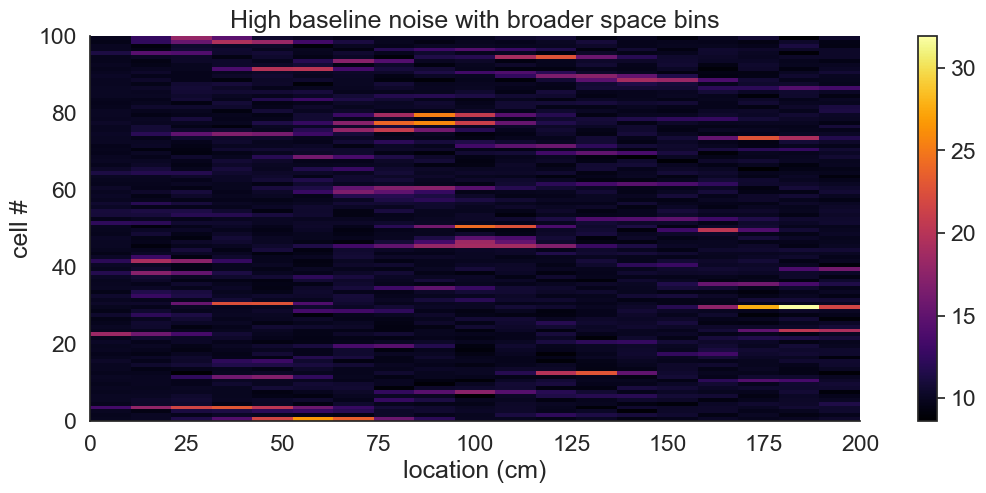

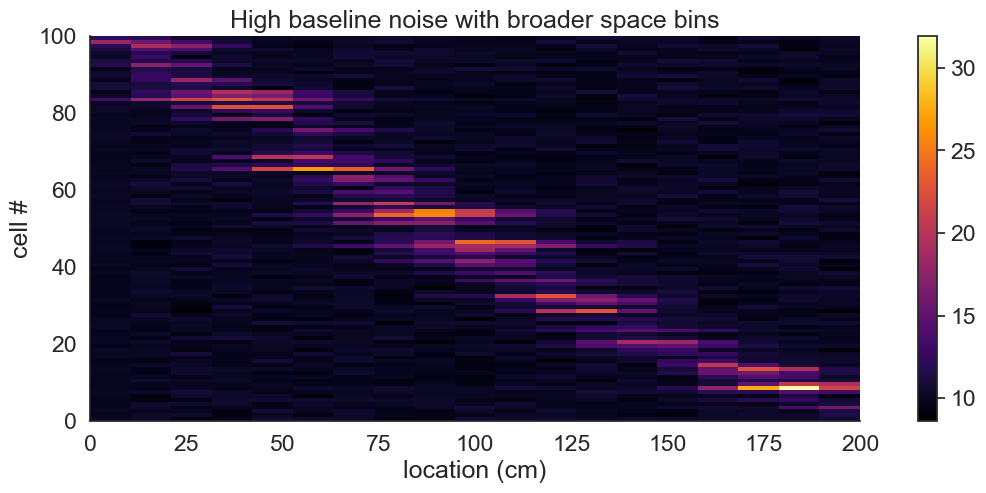

In [ ]:
# B part 2

noise_firing_rate = 10 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

spike_positions = [np.interp(s, t, x) for s in spikes]

space_bins = np.arange(0., 200., 10.) # increased the space bin broadness

# we compute histograms for eaxh cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title("High baseline noise with broader space bins")

plt.figure(figsize=(15,5))
peak_locations = firing_rate_maps.argmax(axis=1)
ix = np.argsort(peak_locations)
plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title("High baseline noise with broader space bins")

# With broader spatial bins the background looks less noisy that with the 
# smaller spatial bins (last figure above has 5 and this one 10), So increasing the
# broadness of spatial bins the firing rate maps become more visuably clear

100%|██████████| 72/72 [00:31<00:00,  2.31it/s]


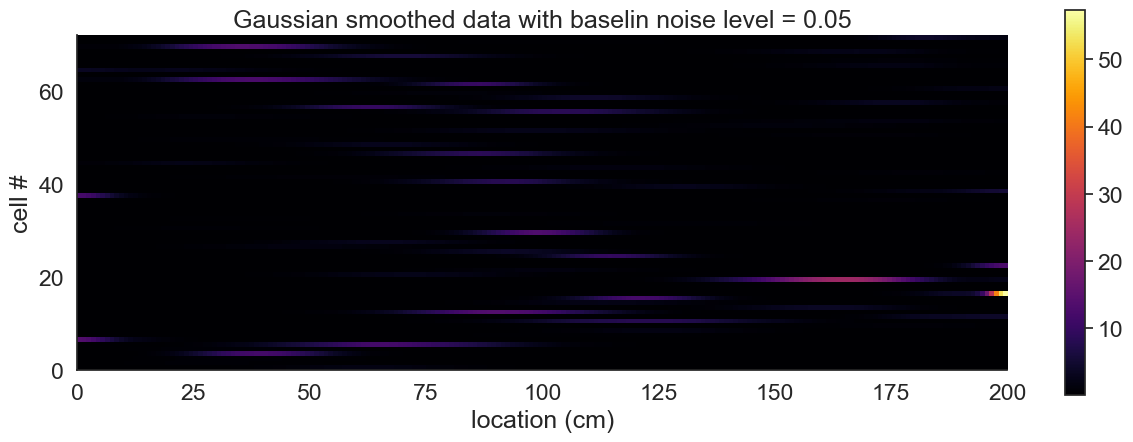

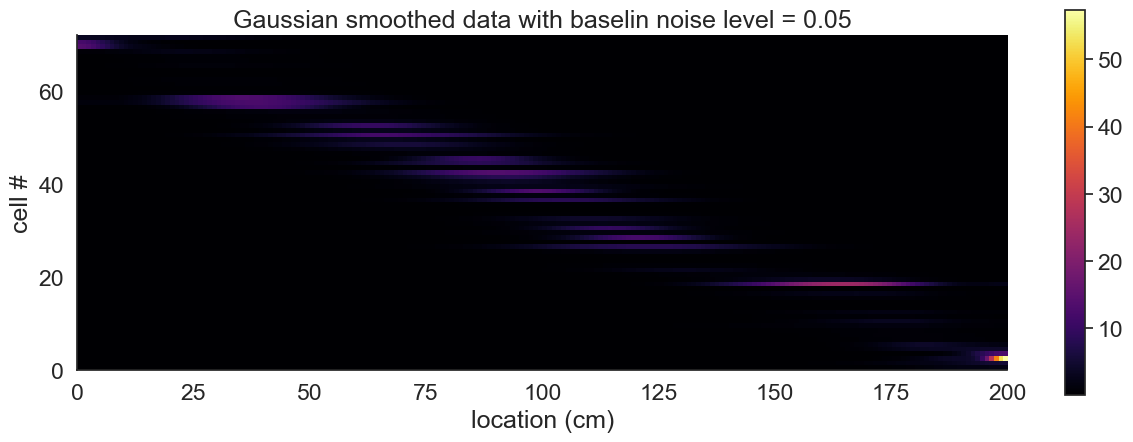

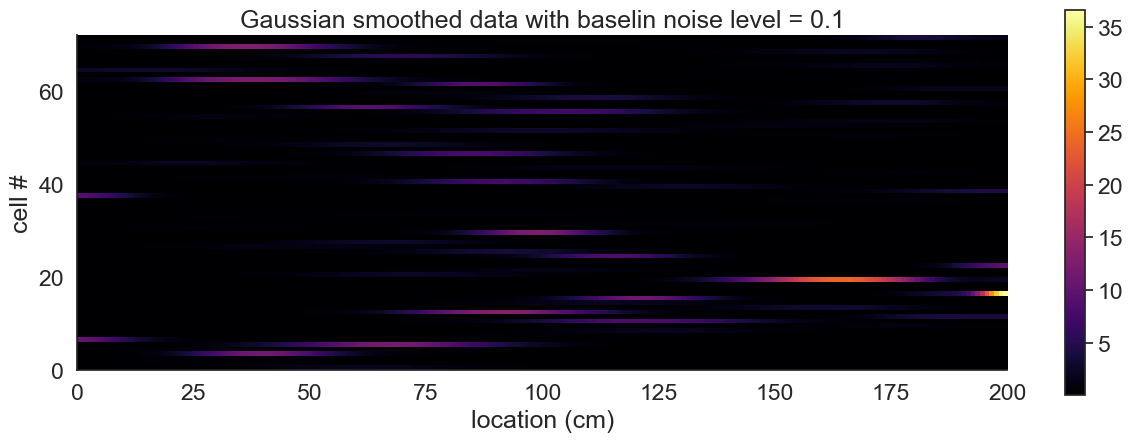

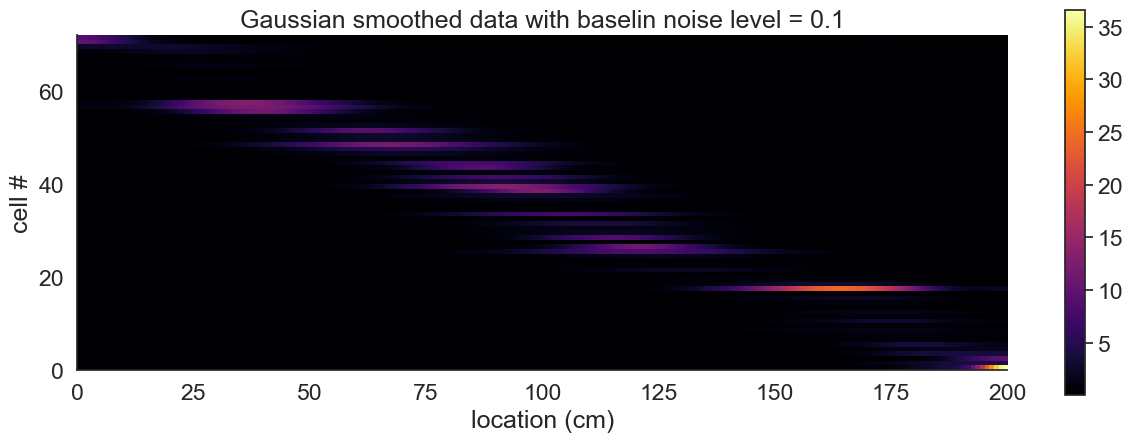

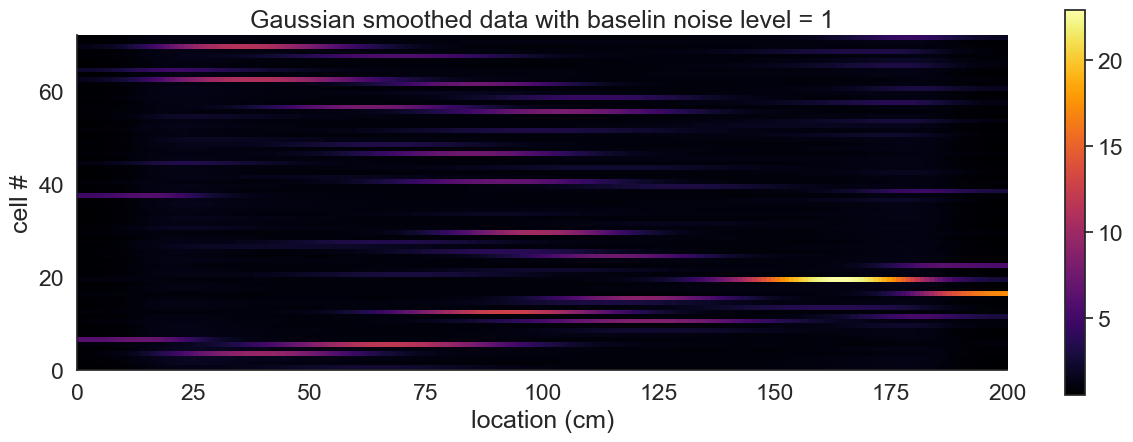

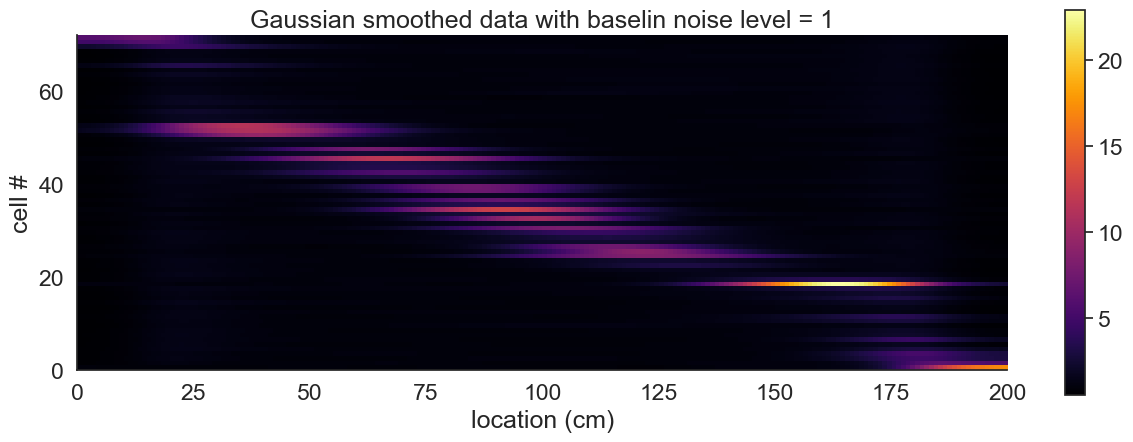

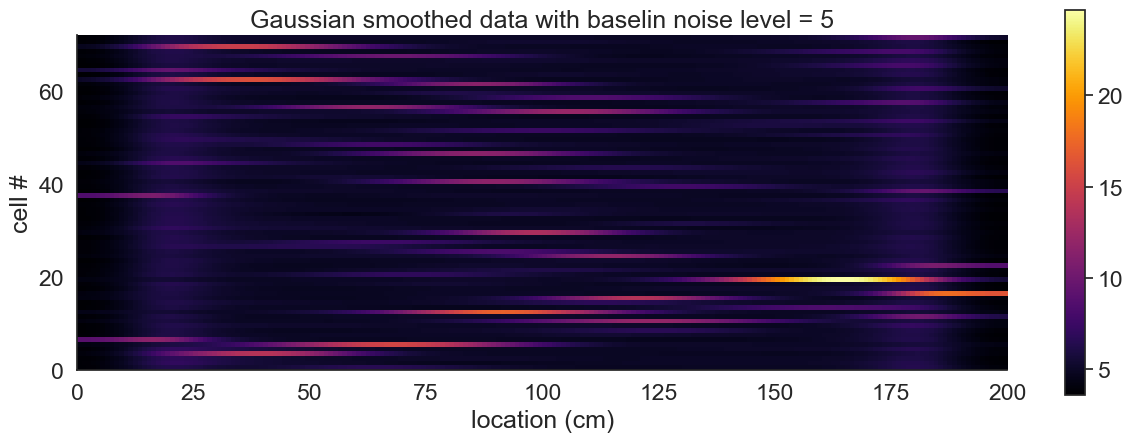

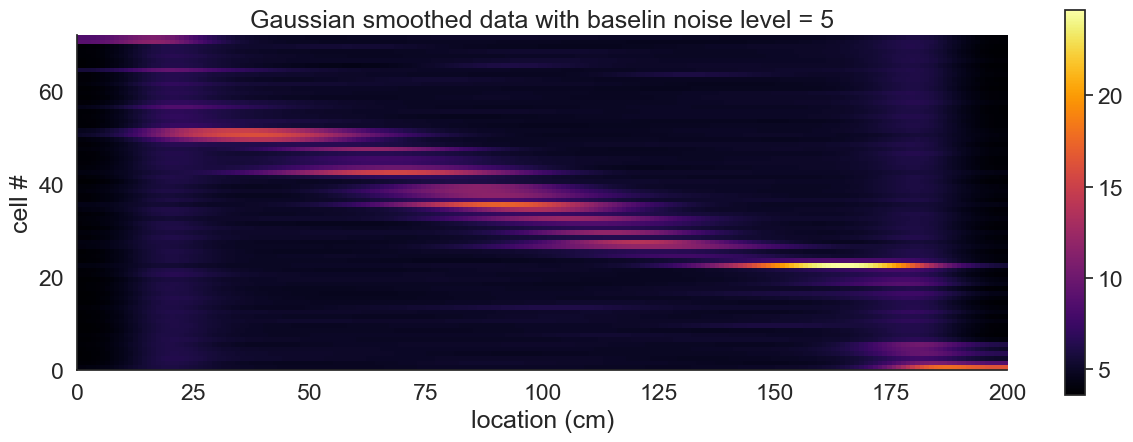

In [ ]:
#1C
from scipy.stats import gaussian_kde

noise_levels = [0.05, 0.1, 1, 5]
space_bins = np.arange(0, 200 , 1.)
occupancy_kde = gaussian_kde(x)
occupancy_values = occupancy_kde(space_bins) # Apply KDE to the animal's positions to estimate the smoothed occupancy
                                             # distribution. This is used later to correct for how much time the animal
                                             # spent at each location.
total_time = len(x) / fps

for noise_firing_rate in noise_levels:
    spikes = []
    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)

    spike_positions = [np.interp(s.flatten(), t, x) for s in spikes]

    final_values = []

    for s in spike_positions:
        data = s.flatten()

        kde = gaussian_kde(data)
        spike_density = kde(space_bins)

        mean_rate = len(data) / total_time

        rate_map = mean_rate * spike_density / occupancy_values # because the gaussian KDE makes the area one, the effect
                                                                # of firing rate dissapears, so multuply it by firing rate
        final_values.append(rate_map)

    final_values = np.vstack(final_values)

    # Plot the normal and the sorted firing rate maps
    plt.figure(figsize=(15,5))
    plt.imshow(final_values, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Gaussian smoothed data with baselin noise level = {noise_firing_rate}")

    plt.figure(figsize=(15,5))
    peak_locations = final_values.argmax(axis=1)
    ix = np.argsort(peak_locations)
    plt.imshow(final_values[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Gaussian smoothed data with baselin noise level = {noise_firing_rate}")

    # The gaussian KDE smoother makes the firing rate maps smoother and reduces random
    # fluctuations. Again with high baseline noise the place fields become less clear'
    # due to the non location specific noise

[175.70944579  98.54552849  38.04318822 152.19735363  70.34220516
 153.99499053 160.0179326   18.46835941  99.8438203   38.46480686
  86.77645521 182.5696555   89.08207591 106.77909955 168.21903118
  67.10923128 102.71130058  55.85414387 160.86096844 126.74714365
  98.37645621 136.62528528  68.6531031   73.68366361 104.93816908
  85.63132088  96.80352048  29.68644577 113.09141859 161.80147242
  77.02370187  90.70603899 123.50084117 187.22156701   6.39354336
 148.49539997  85.79654455  88.2695096   90.79496084  79.1169323
 108.39000411  56.44780217  98.13147046  95.37881055  74.63664151
  69.30269802  93.33076957 110.9565582  100.91011496 192.37681262
  99.51184723  76.05738698 164.0259411  102.74872564 101.11790647
 194.54680375 117.92725905 108.6826716  148.7450223   92.03427167
 183.14014265 120.02449934 157.75492812 115.37768164 101.71294327
   6.16370063  68.92709003  55.04276528  44.65442825  70.01486833
  55.369808    72.29038507  91.77189657 134.49641789  56.61462105
 193.475797

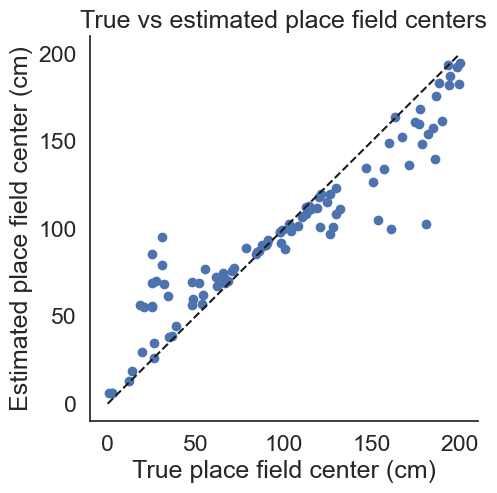

In [ ]:
#D
# Ran the simulation again in the code in cell 3 before running the code in the current cell
center = []

# Centers of masses calculated with the formule
for s in spike_positions:
    data = s.flatten()
    center.append(np.mean(data))

center = np.array(center)

print(center)

# Calculated center of mass plotted against the simulated center of mass
plt.figure(figsize=(5,5))
plt.scatter(pf_centers, center)
plt.plot([0, 200], [0, 200], 'k--')
plt.xlabel("True place field center (cm)")
plt.ylabel("Estimated place field center (cm)")
plt.title("True vs estimated place field centers")
plt.show()

# The estimated center is just the average of the spike locations per cell.
# While the real center of the place field of the cells is pf_center in this line of code:
# pf_centers = np.random.rand(n_cells) * track_length, so just random numbers between 0 and 1,
# multiplied with the length of the track

## Exercise 2 - mutual information
---
A - Implement the mutual information formula discussed in the lesson, and apply it to the place cell data we simulated.

B - Adapt the simulation so that you can systematically vary 1) Peak firing rate, 2) place cell size 3) baseline noise. 
Study how mutual information vary with these parameters. Use both definition of mutual information above, and discuss the differences between them. Make some plots to show how the dependency goes.

In [ ]:
# Simulate the data again. All copied from the tuning-curves.ipynb file
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells)

bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    x = np.concatenate((x, stop1, run1, stop2, run2))
t = np.arange(len(x))/fps

sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

spike_positions = [np.interp(s, t, x) for s in spikes]

space_bins = np.arange(0., 200., 5.)

# we compute histograms for eaxh cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


Text(0.5, 1.0, 'Spatial information per cell')

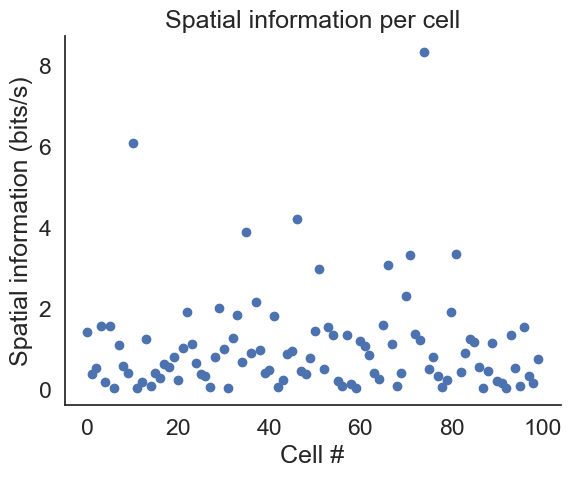

In [ ]:
#2A
occupancy_prob = occupancy/np.sum(occupancy) # make list with the probability of occupancy per position
info = []
epsilon = 1e-15

for current_cell in firing_rate_maps:
    labda = np.sum(current_cell*occupancy_prob) # mean firing rate with  labda = integral over x labda(x)*p(x) dx

    current_info = [] 

    for i in range(len(current_cell)): #for loop where per cell per position the information is calculated
        current_info.append(current_cell[i]*np.log2((current_cell[i] + epsilon)/labda)*occupancy_prob[i])
    
    info.append(np.sum(current_info)) 

plt.scatter(np.arange(len(info)), info) # scatter plot of firing rates per cell
plt.xlabel("Cell #")
plt.ylabel("Spatial information (bits/s)")
plt.title("Spatial information per cell")


In [ ]:
print(len(info))

100


In [11]:
#2B
# make the code into a figure so the function can be called and the peak fireing rate, cell size and baseline noise can be altered
def simulation(peak_fire_rate, cell_size, base_noise):
    # Simulate the data again. All copied from the tuning-curves.ipynb file
    track_length = 200. # the length of our linear track (eg in centimeter)
    average_firing_rate = peak_fire_rate # the peak firing rate, averaged across the population 
    n_cells = 100 # how many cells we are recording
    pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
    pf_size = np.random.gamma(10, size=n_cells) * cell_size# the size (width) of the place fields, drawn randomly from a gamma distribution 
    pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells)

    bins = np.arange(0., 200.)
    true_firing_rate_maps = np.zeros((n_cells, len(bins)))
    for i in range(n_cells):
        true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

    n_runs = 20 
    av_running_speed = 10 # the average running speed (in cm/s)
    fps = 30 # the number of "video frames" per second 
    running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
    running_speed_b = np.random.chisquare(10, size=n_runs) 

    stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
    stopping_time_b = np.random.chisquare(15, size=n_runs)

    x = np.array([])
    for i in range(n_runs):
        stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
        run_length = len(bins) * fps / running_speed_a[i]
        run1 = np.linspace(0., float(len(bins)-1), int(run_length))
        stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
        run_length = len(bins) * fps / running_speed_b[i]
        run2 = np.linspace(len(bins)-1., 0., int(run_length))
        x = np.concatenate((x, stop1, run1, stop2, run2))
    t = np.arange(len(x))/fps

    sampling_rate = 10000.
    t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
    x_sampling = np.floor(np.interp(t_sampling, t, x))
    noise_firing_rate = base_noise # the baseline noise firing rate
    spikes = []

    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)

    spike_positions = [np.interp(s, t, x) for s in spikes]

    space_bins = np.arange(0., 200., 5.)

# we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_maps = spikes_hist / occupancy 

    return(occupancy, firing_rate_maps) # return these variables which are nessecary for information formulas

100%|██████████| 100/100 [05:42<00:00,  3.43s/it]


Text(0.5, 1.0, 'Mean mutual information over different peak firing rates')

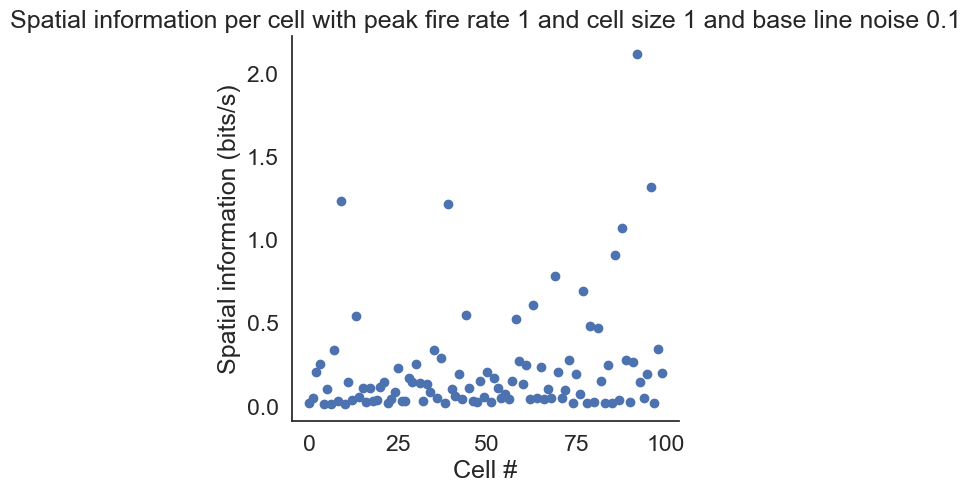

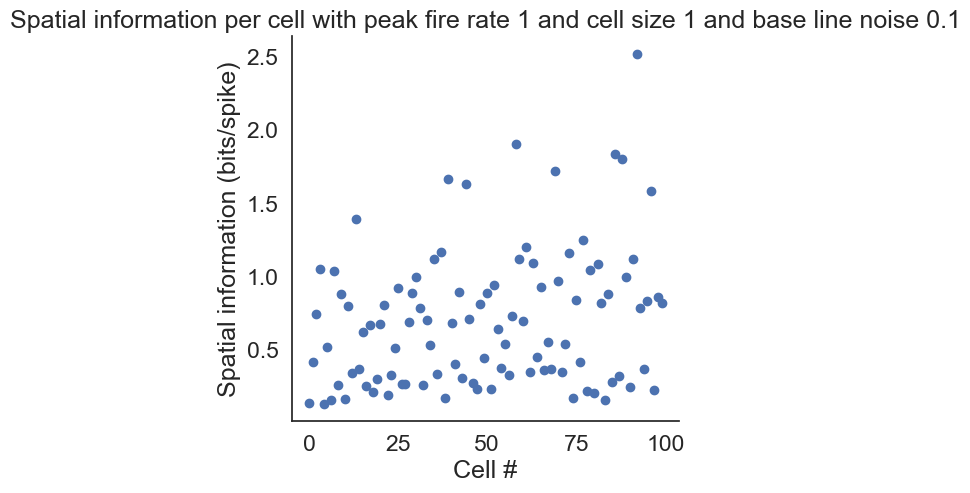

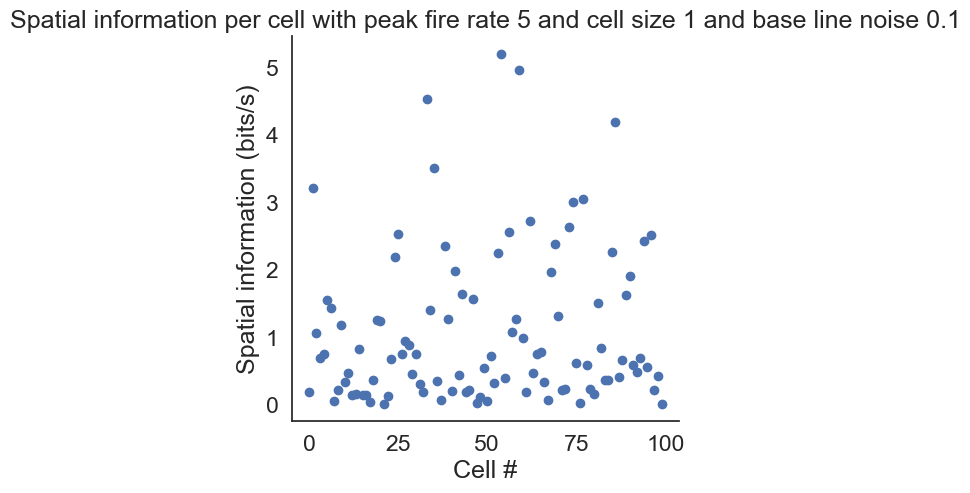

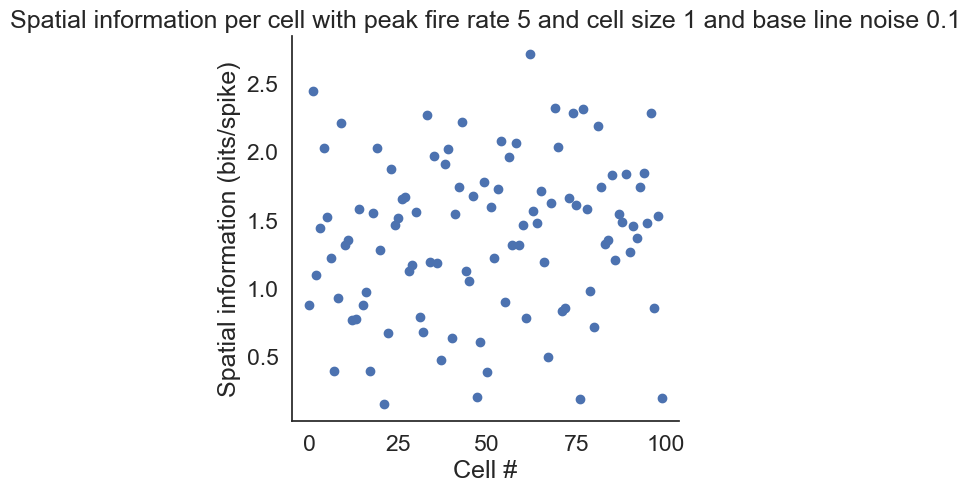

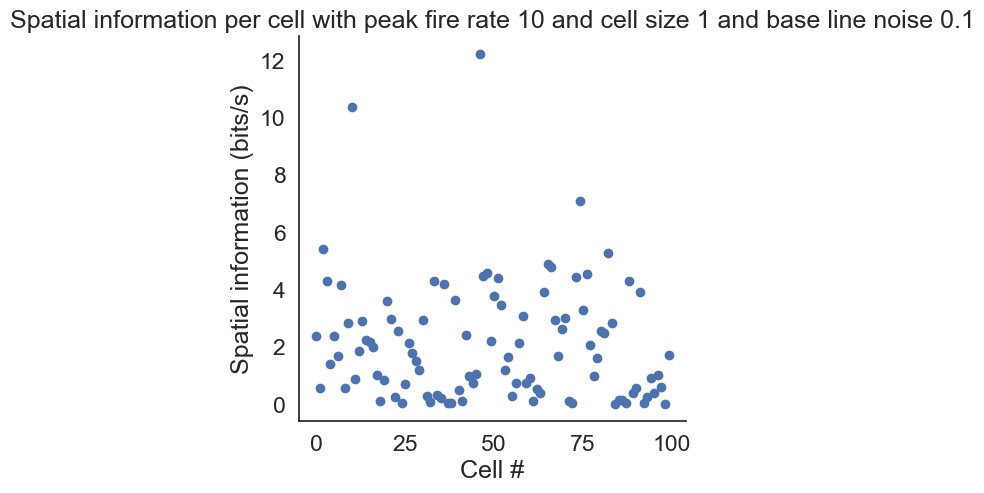

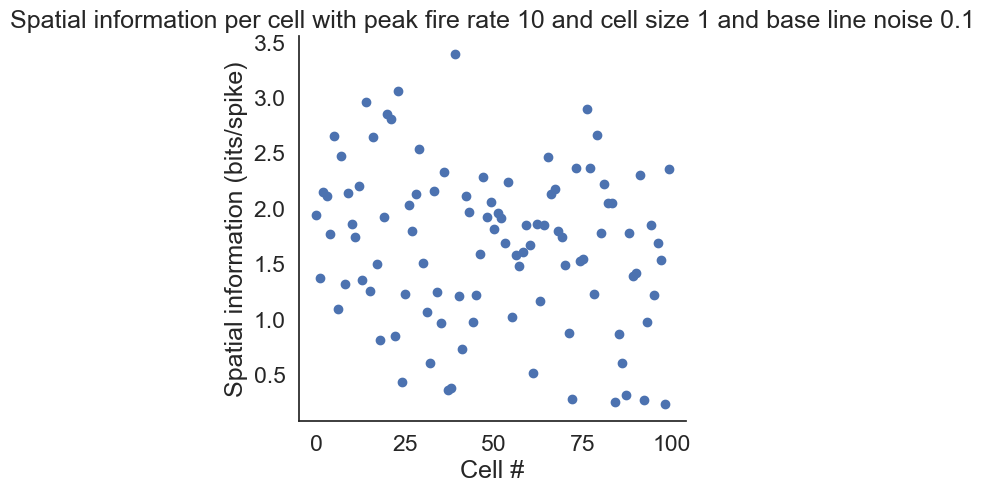

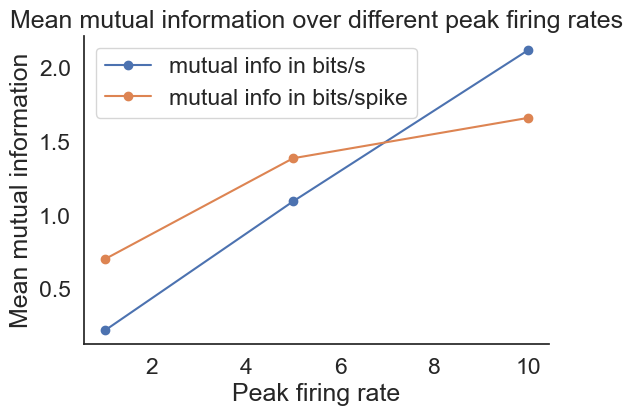

In [12]:
#alter the peak firing rate, cell size and base noise so you can loop over these lists
fire_rate = [1, 5, 10]
cell_size = [0.5, 1, 1.5]
base_noise = [0.05, 0.1, 0.2]
mean_info = []
mean_info_per_spike = []

# Loop over the 3 firing rates while keeping cell size and baseline noise the same
for fr in fire_rate:
    occupancy, firing_rate_maps = simulation(fr, cell_size[1], base_noise[1])

    occupancy_prob = occupancy/np.sum(occupancy) # make list with the probability of occupancy per position
    info = []
    info_per_spike = []
    epsilon = 1e-15
    c = -1

    for current_cell in firing_rate_maps:
        labda = np.sum(current_cell*occupancy_prob) # mean firing rate with  labda = integral over x labda(x)*p(x) dx
        c=c+1

        current_info = [] 
        

        for i in range(len(current_cell)): #for loop where per cell per position the information is calculated
            current_info.append(current_cell[i]*np.log2((current_cell[i] + epsilon)/labda)*occupancy_prob[i])
    
        info.append(np.sum(current_info)) 
        info_per_spike.append(info[c]/labda) # also calculate the information per spike per cell

    mean_info.append(np.mean(info))
    mean_info_per_spike.append(np.mean(info_per_spike))

#plot bits per sec and bits per spike per cell for the 3 different peak firing rates
    plt.figure(figsize=(5,5))
    plt.scatter(np.arange(len(info)), info) 
    plt.xlabel("Cell #")
    plt.ylabel("Spatial information (bits/s)")
    plt.title(f"Spatial information per cell with peak fire rate {fr} and cell size {cell_size[1]} and base line noise {base_noise[1]}")

    plt.figure(figsize=(5,5))
    plt.scatter(np.arange(len(info)), info_per_spike) 
    plt.xlabel("Cell #")
    plt.ylabel("Spatial information (bits/spike)")
    plt.title(f"Spatial information per cell with peak fire rate {fr} and cell size {cell_size[1]} and base line noise {base_noise[1]}")

plt.figure(figsize=(6,4))
plt.plot(fire_rate, mean_info, marker='o', label='mutual info in bits/s')
plt.plot(fire_rate, mean_info_per_spike, marker='o', label='mutual info in bits/spike')
plt.xlabel("Peak firing rate")
plt.ylabel("Mean mutual information")
plt.legend()
plt.title("Mean mutual information over different peak firing rates")


    # As you can see in the plots, when increasing the peak firing rate per cell in both
    # definitions of mutual information the information per cell increases, but some more
    # in the definiton that uses bits/s, which makes sense, because spikes contain information,
    # so the more spikes per second the more inforamtion per second, and with the information per spike
    # you devide and thus correct by mean firing rate of the cell, so increasing the firing rate has somewhat less effect
    # As you can see in the mean info plots at the bottom
    # Besides this the distribution of info per cell is more uniform and with less outliers
    # in the bits/spike. In the bits/s there are some outlier cells that provide much more bit/s,
    # because they have a higher firing rate than the other cells

100%|██████████| 100/100 [00:57<00:00,  1.75it/s]


Text(0.5, 1.0, 'Mean mutual information over different cell sizes')

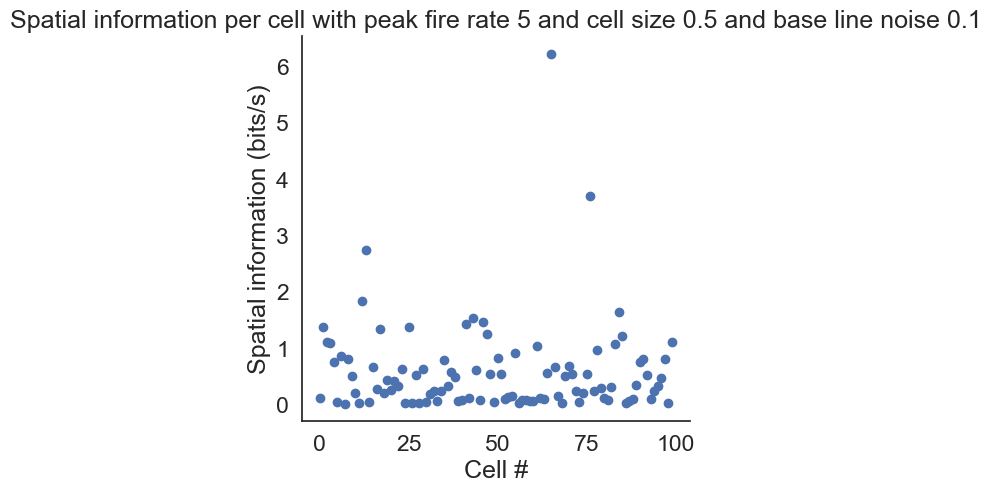

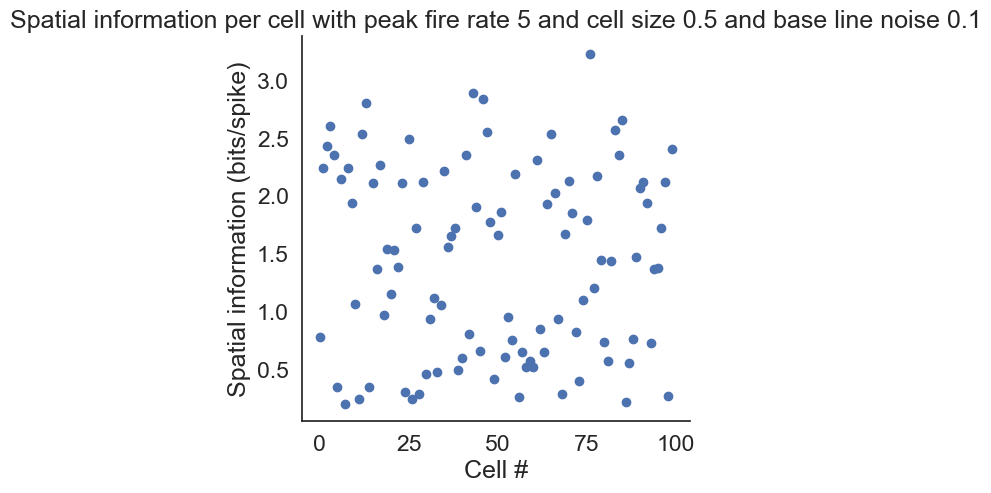

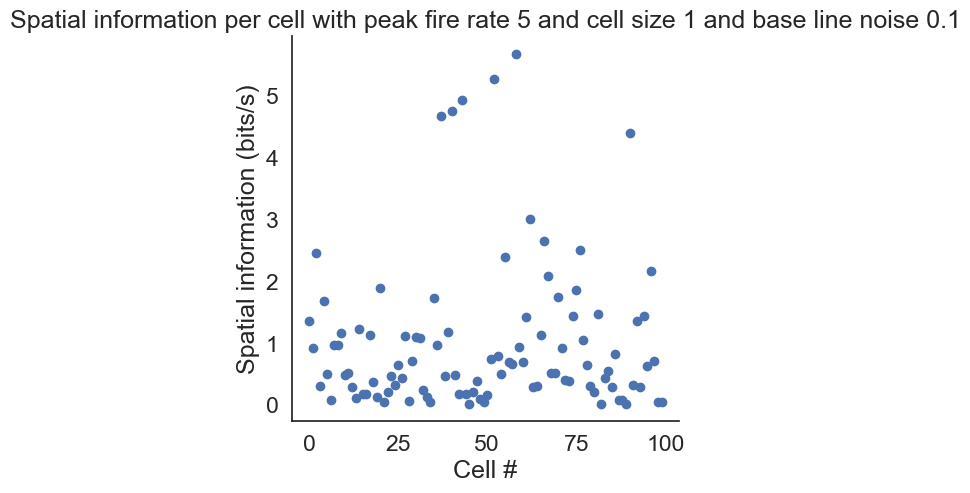

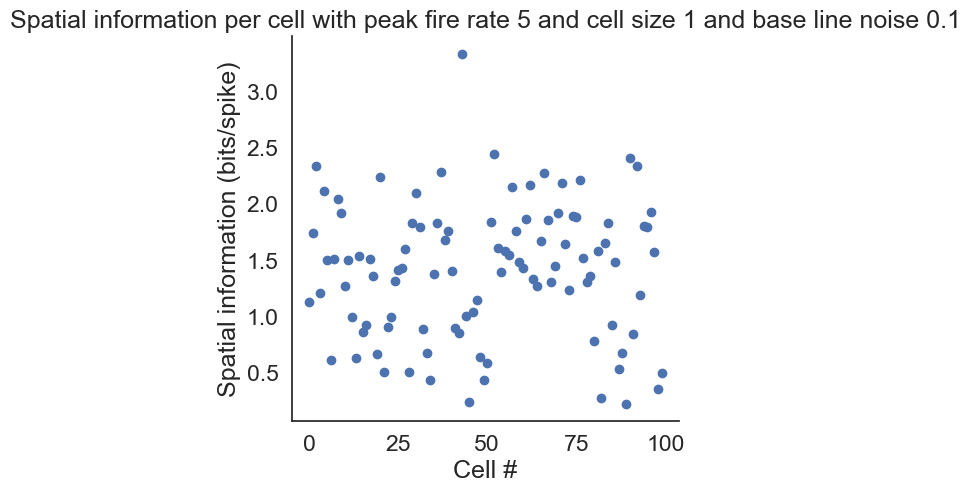

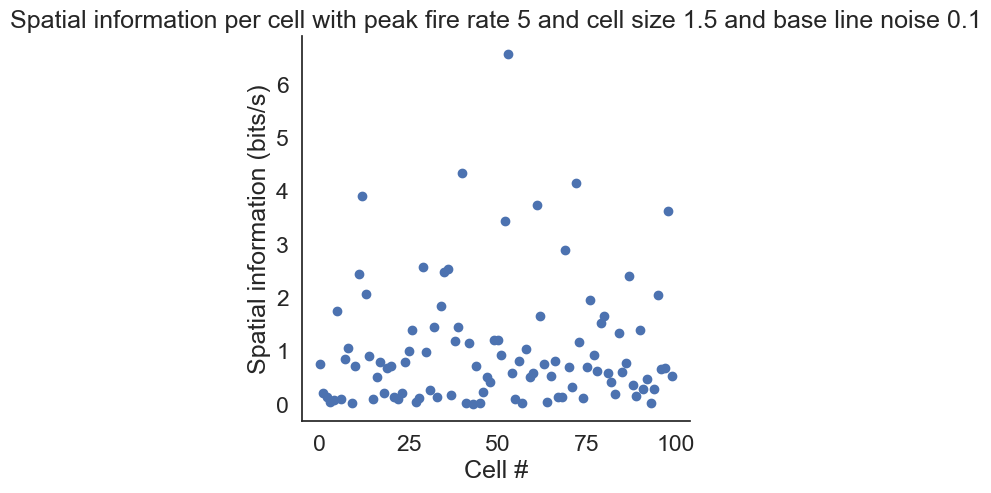

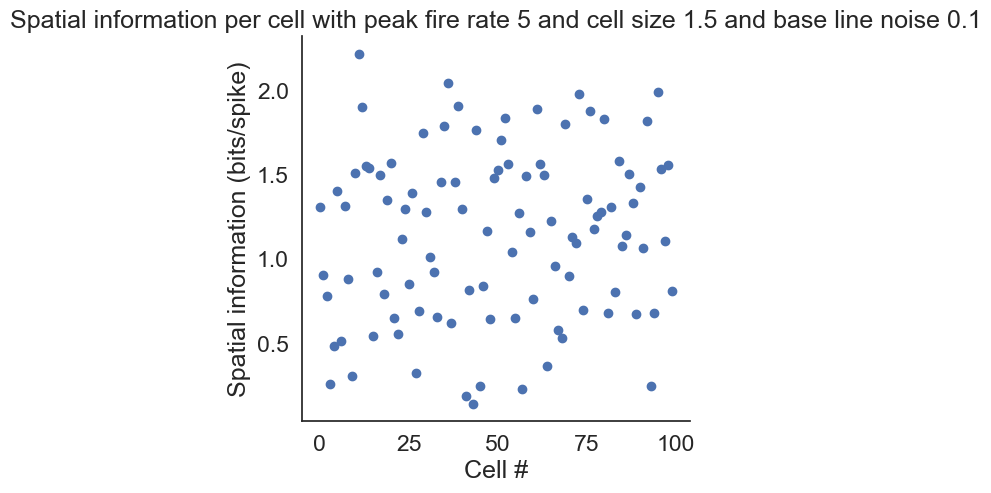

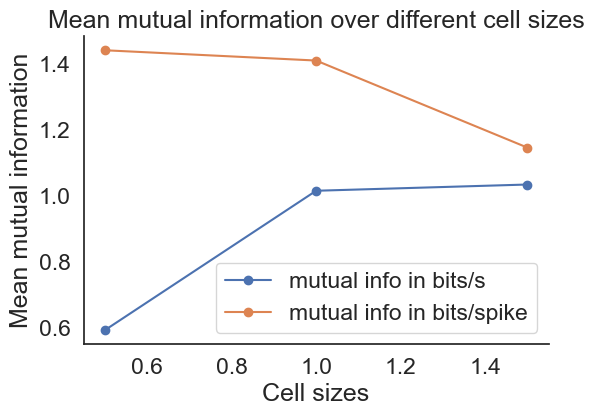

In [ ]:
# Same as with altering firing rate, but now alter cell size
fire_rate = [1, 5, 10]
cell_size = [0.5, 1, 1.5]
base_noise = [0.05, 0.1, 0.2]
mean_info = []
mean_info_per_spike = []

# Loop over the 3 firing rates while keeping cell size and baseline noise the same
for cs in cell_size:
    occupancy, firing_rate_maps = simulation(fire_rate[1], cs, base_noise[1])

    occupancy_prob = occupancy/np.sum(occupancy) # make list with the probability of occupancy per position
    info = []
    info_per_spike = []
    epsilon = 1e-15
    c = -1

    for current_cell in firing_rate_maps:
        labda = np.sum(current_cell*occupancy_prob) # mean firing rate with  labda = integral over x labda(x)*p(x) dx
        c=c+1

        current_info = [] 
        

        for i in range(len(current_cell)): #for loop where per cell per position the information is calculated
            current_info.append(current_cell[i]*np.log2((current_cell[i] + epsilon)/labda)*occupancy_prob[i])
    
        info.append(np.sum(current_info)) 
        info_per_spike.append(info[c]/labda) # also calculate the information per spike per cell
    
    mean_info.append(np.mean(info))
    mean_info_per_spike.append(np.mean(info_per_spike))
        
#plot bits per sec and bits per spike per cell for the 3 different peak firing rates
    plt.figure(figsize=(5,5))
    plt.scatter(np.arange(len(info)), info) 
    plt.xlabel("Cell #")
    plt.ylabel("Spatial information (bits/s)")
    plt.title(f"Spatial information per cell with peak fire rate {fire_rate[1]} and cell size {cs} and base line noise {base_noise[1]}")

    plt.figure(figsize=(5,5))
    plt.scatter(np.arange(len(info)), info_per_spike) 
    plt.xlabel("Cell #")
    plt.ylabel("Spatial information (bits/spike)")
    plt.title(f"Spatial information per cell with peak fire rate {fire_rate[1]} and cell size {cs} and base line noise {base_noise[1]}")

plt.figure(figsize=(6,4))
plt.plot(cell_size, mean_info, marker='o', label='mutual info in bits/s')
plt.plot(cell_size, mean_info_per_spike, marker='o', label='mutual info in bits/spike')
plt.xlabel("Cell sizes")
plt.ylabel("Mean mutual information")
plt.legend()
plt.title("Mean mutual information over different cell sizes")

# Increasing the cell size increases its place fields, which means it fires at more locations
# So on average the bits/sec per cell increases with this, however each spike is less
# specific on the location, so the info per spike decreases. This is also what you can see 
# in the plot in the bottom.

In [ ]:
np.mean(info)

np.float64(0.9475215543778626)

100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


Text(0.5, 1.0, 'Mean mutual information over different levels of baseline noise')

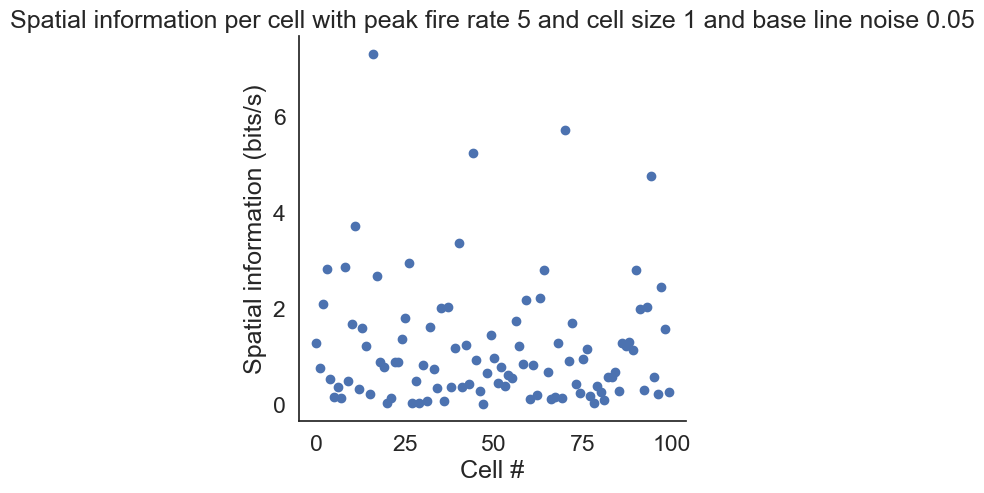

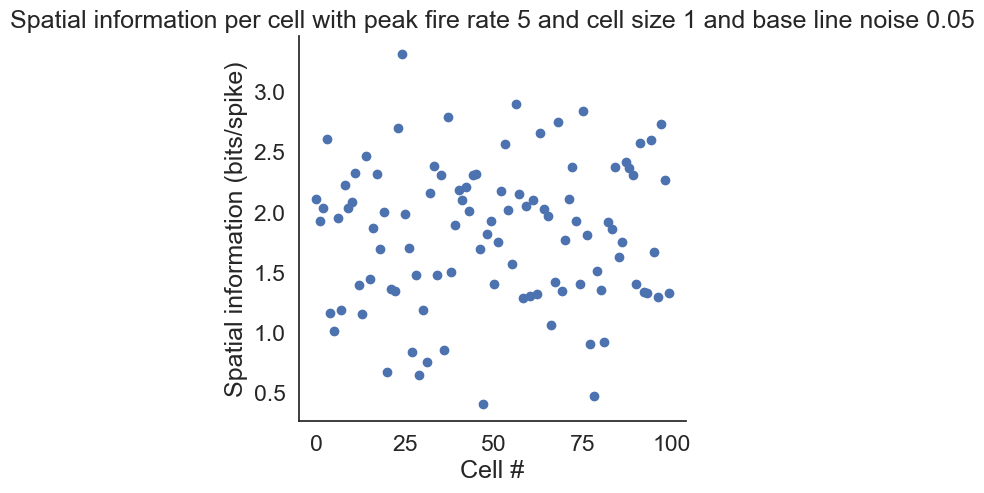

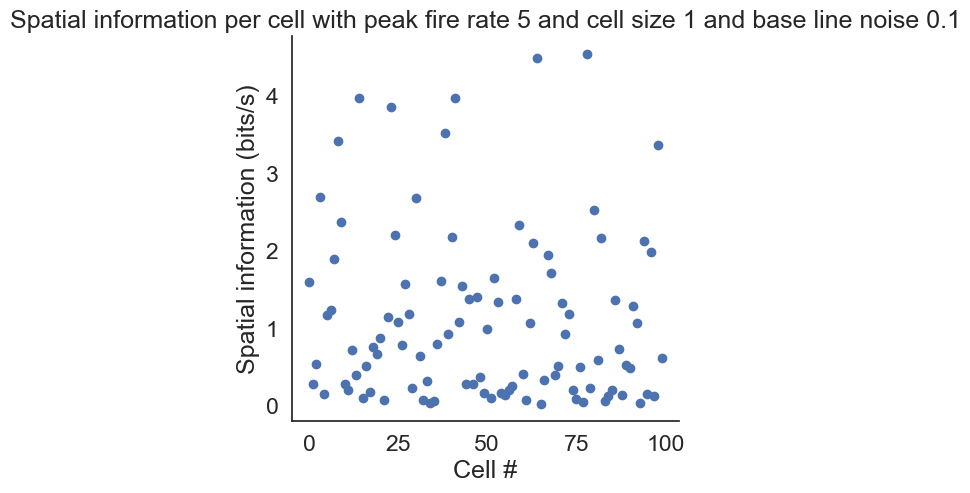

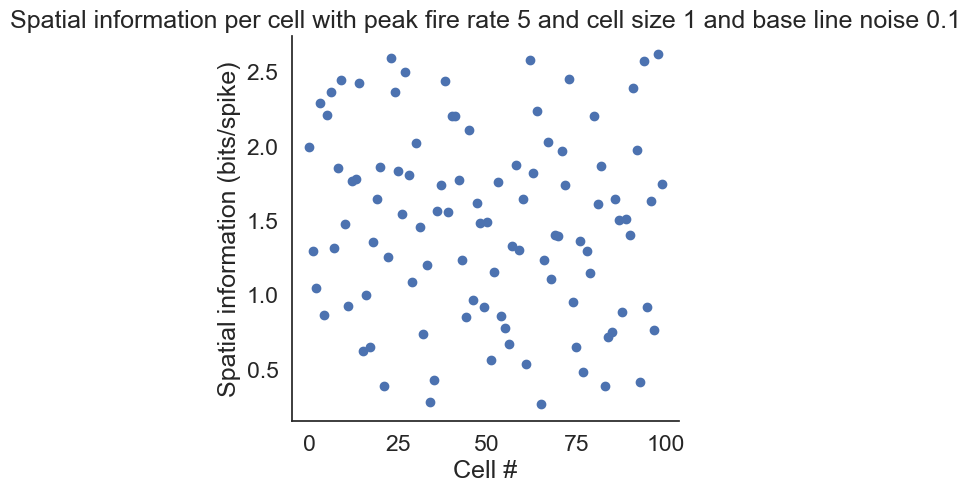

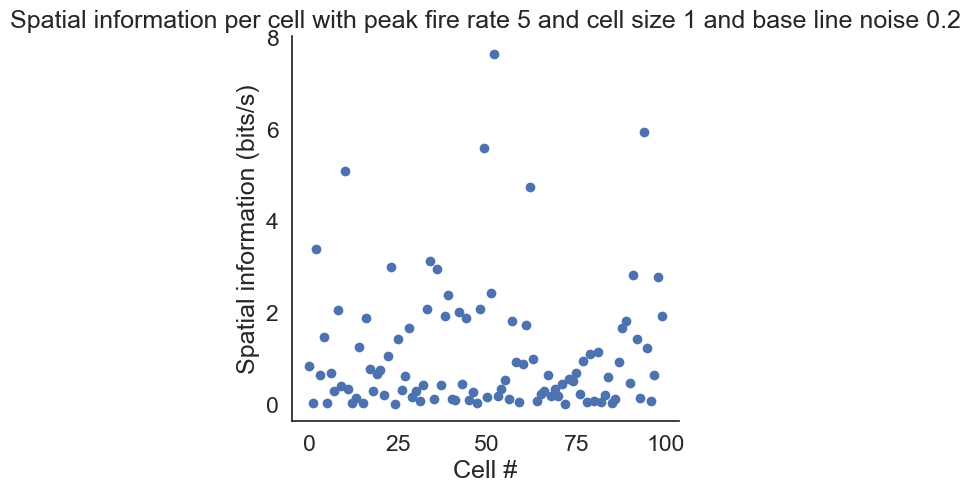

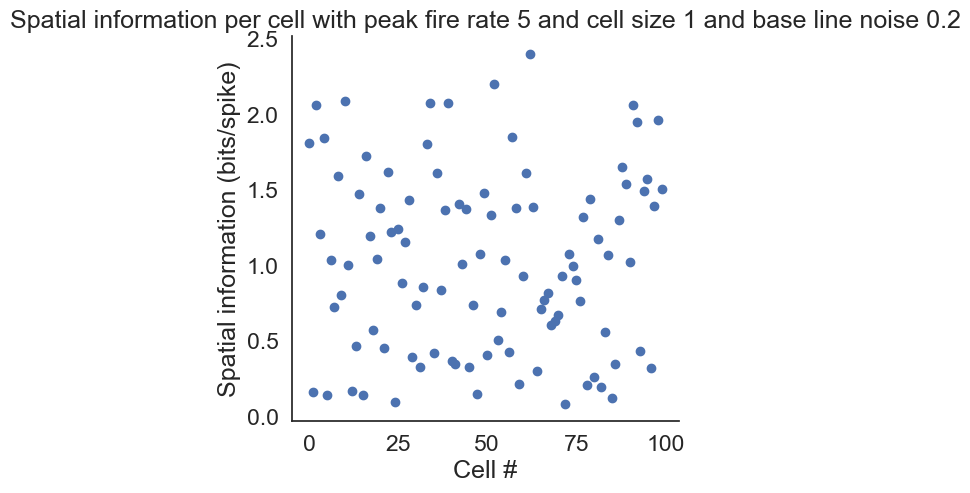

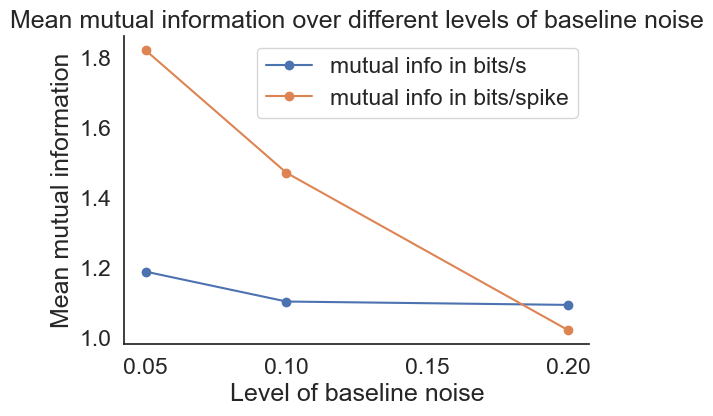

In [ ]:
# Same as with altering firing rate and cell size, but now alter baseline noise
fire_rate = [1, 5, 10]
cell_size = [0.5, 1, 1.5]
base_noise = [0.05, 0.1, 0.2]
mean_info = []
mean_info_per_spike = []

# Loop over baseline noise levels while keeping cell size and firing rate the same
for bn in base_noise:
    occupancy, firing_rate_maps = simulation(fire_rate[1], cell_size[1], bn)

    occupancy_prob = occupancy/np.sum(occupancy) #  structure with the probability of occupancy per position
    info = []
    info_per_spike = []
    epsilon = 1e-15
    c = -1

    for current_cell in firing_rate_maps:
        labda = np.sum(current_cell*occupancy_prob) # mean firing rate with  labda = integral over x labda(x)*p(x) dx
        c=c+1

        current_info = [] 
        

        for i in range(len(current_cell)): #for loop where per cell per position the information is calculated
            current_info.append(current_cell[i]*np.log2((current_cell[i] + epsilon)/labda)*occupancy_prob[i])
    
        info.append(np.sum(current_info)) 
        info_per_spike.append(info[c]/labda) # also calculate the information per spike per cell
    
    mean_info.append(np.mean(info))
    mean_info_per_spike.append(np.mean(info_per_spike))
        
#plot bits per sec and bits per spike per cell for the 3 different peak firing rates
    plt.figure(figsize=(5,5))
    plt.scatter(np.arange(len(info)), info) 
    plt.xlabel("Cell #")
    plt.ylabel("Spatial information (bits/s)")
    plt.title(f"Spatial information per cell with peak fire rate {fire_rate[1]} and cell size {cell_size[1]} and base line noise {bn}")

    plt.figure(figsize=(5,5))
    plt.scatter(np.arange(len(info)), info_per_spike) 
    plt.xlabel("Cell #")
    plt.ylabel("Spatial information (bits/spike)")
    plt.title(f"Spatial information per cell with peak fire rate {fire_rate[1]} and cell size {cell_size[1]} and base line noise {bn}")

plt.figure(figsize=(6,4))
plt.plot(base_noise, mean_info, marker='o', label='mutual info in bits/s')
plt.plot(base_noise, mean_info_per_spike, marker='o', label='mutual info in bits/spike')
plt.xlabel("Level of baseline noise")
plt.ylabel("Mean mutual information")
plt.legend()
plt.title("Mean mutual information over different levels of baseline noise")

# Increasing baseline noise adds extra spikes that are not location-specific.
# These spikes increase the overall firing rate, but they do not add much useful
# info,so, the information per spike decreases (and thus lower bit/spike). The
# information in bits/s remains quite stable, because the higher number
# of spikes is partly balanced by the lower info of each spike.

## Exercise 3 - working with real data
---
Load the data from `linear_track_data.pickle`. It contains neural recordings from a mouse running on a linear track.
- `x` contains the position of the animal
- `t` contains the corresponding times, in seconds
- `spikes` contains a list of lists. Each list contains the timestamps of the spikes emitted by a neuron.

A - Visualiaze the position a s a function of time. Plot the spike of a selected cell in space.

B - Calculate the firing rate maps for all the cells, and plot them sorted by increasing peak positon.

C - Calculate the spatial information for each cell, and plot the distribution. Plot the firing rate maps of the 5 cells with lower spatial information, and the firing rate maps of the 5 cells with higher spatial information. Comment on the differences.

C:\Users\larsb\AppData\Local\Temp\ipykernel_23356\2257021592.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(handle)


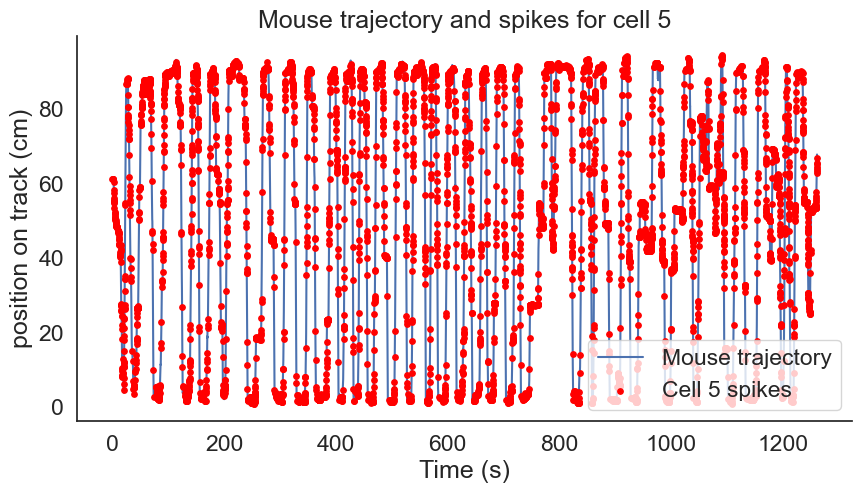

In [9]:
#3A
#import the data and give names to the variables in the data
with open('data/linear_track_data.pickle', 'rb') as handle:
    data = pickle.load(handle)

position = data["x"]
time = data["t"]
spike_times_real = data["spikes"]

cell_id = 5
cell_spikes = spike_times_real[cell_id]
spike_positions = np.interp(cell_spikes, time, position)



# Plot of the position of the mouse as a fucntion of time
plt.figure(figsize=(10,5))
plt.plot(time, position,label='Mouse trajectory')
plt.xlabel('Time (s)')
plt.ylabel('position on track (cm)')
plt.scatter(cell_spikes, spike_positions, color='red', label=f'Cell {cell_id} spikes', s=15, zorder=5)
plt.title(f'Mouse trajectory and spikes for cell {cell_id}')
plt.legend(loc='lower right')

In [10]:
print(np.max(position))
print(np.min(position))

n_cells = len(spike_times_real)

space_bins = np.arange(0., 96., 1.)
print(n_cells)

94.96118975101513
0.817624338876868
72


In [11]:
spike_pos = []

#interprolate the spike times on to a new time axis corresponding with position
for i in range(len(spike_times_real)):
    spike_pos.append(np.interp(spike_times_real[i], time, position))

# frame rate of video
fps = 1/np.mean((np.diff(time)))

# we compute histograms for eaxh cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_pos]
# put them together into a matrix of floating point numbers (for plotting)
spikes_hist = np.vstack(spikes_hist).astype(np.float64)
# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(position, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

    

In [12]:
print(np.sum(occupancy == 0))
print(np.sum(np.isnan(occupancy))) # in both cases it is 0 so dont have to account for this

0
0


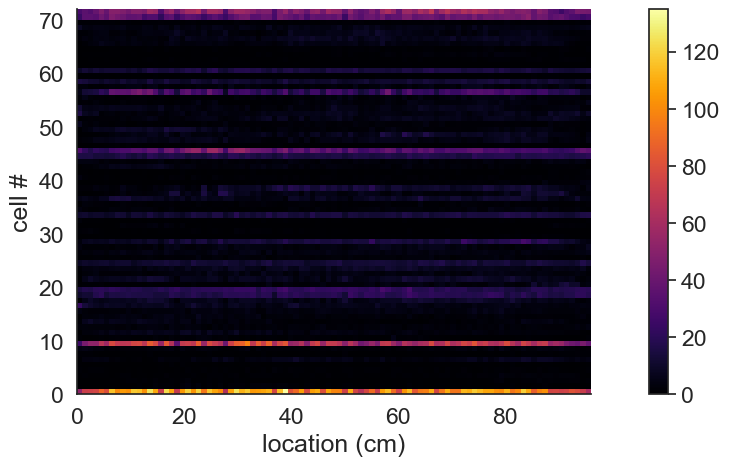

In [13]:
# plot the non-sorted firerate maps
plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 96, 0, 72])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()


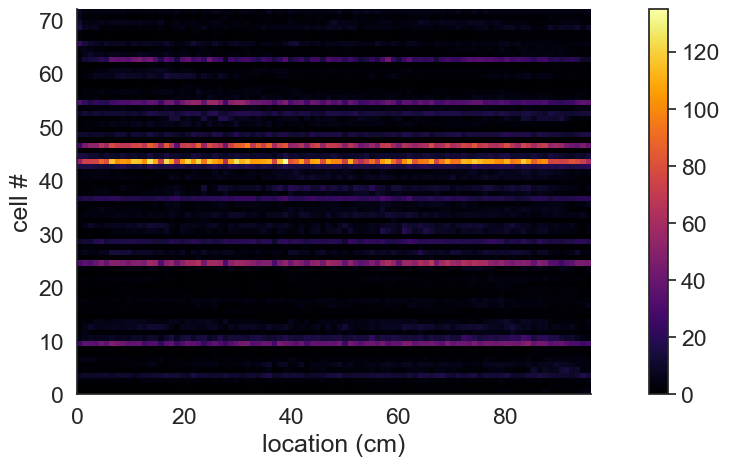

In [14]:
#Same plot, but sorterd by peak position
plt.figure(figsize=(15,5))
peak_locations = firing_rate_maps.argmax(axis=1)
ix = np.argsort(peak_locations)
plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 96, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()

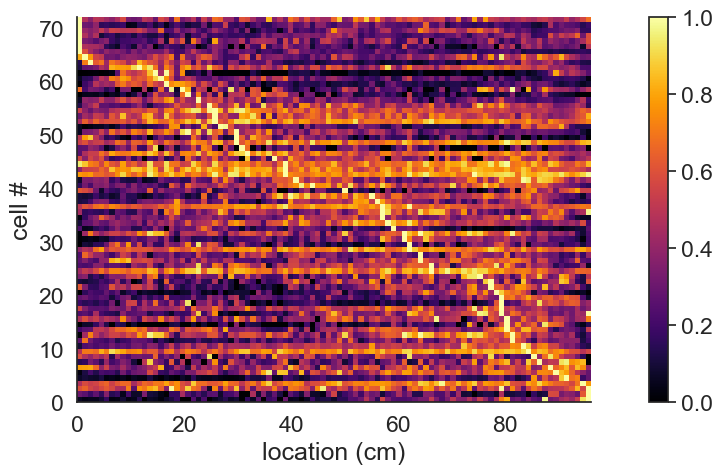

In [15]:
# Normalize each cell's firing-rate map by its own maximum firing rate.
# The cells are then sorted by their peak firing location.
# This makes spatial firing patterns easier to visualize, because cells with
# very high firing rates, such as broadly firing interneurons, otherwise dominate
# the color scale and suppress the visibility of lower-rate place cells.

max_per_row = np.max(firing_rate_maps,axis=1)

normal_fire_rate = []

for i in range(len(firing_rate_maps)):
    normal_fire_rate.append(firing_rate_maps[i]/max_per_row[i])

normal_fire_rate = np.array(normal_fire_rate)

plt.figure(figsize=(15,5))
peak_locations = normal_fire_rate.argmax(axis=1)
ix = np.argsort(peak_locations)
plt.imshow(normal_fire_rate[ix,:], cmap='inferno', extent = [0, 96, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()

In [16]:
#3C
# This code calculates the spatial information per cell in bits/sec and bits/spike
# of real recorded data.
info = []
info_per_spike = []
c=-1
epsilon = 1e-15
occupancy_prob = occupancy/np.sum(occupancy) # structure with the probability of occupancy per position

for current_cell in firing_rate_maps:
        labda = np.sum(current_cell*occupancy_prob) # mean firing rate with  labda = integral over x labda(x)*p(x) dx
        c=c+1

        current_info = [] 
        

        for i in range(len(current_cell)): #for loop where per cell per position the information is calculated
            current_info.append(current_cell[i]*np.log2((current_cell[i] + epsilon)/labda)*occupancy_prob[i])
    
        info.append(np.sum(current_info)) 
        info_per_spike.append(info[c]/labda) # also calculate the information per spike per cell
    



Text(0.5, 1.0, 'Spatial info per cell in bits/spike')

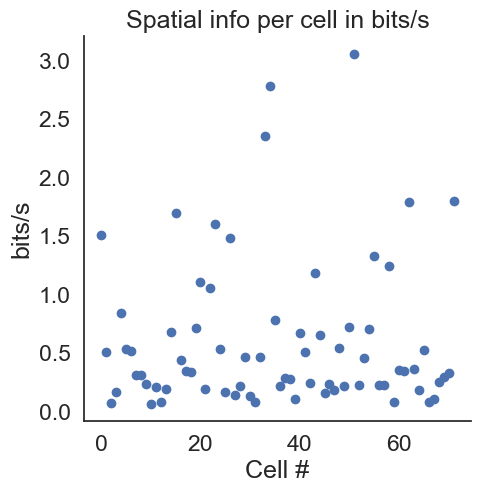

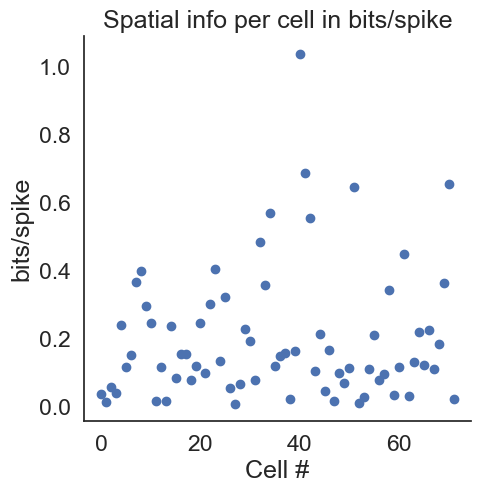

In [17]:
# plot both type of spatial information per cell
plt.figure(figsize=(5,5))
plt.scatter(np.arange(len(info)), info)
plt.xlabel("Cell #")
plt.ylabel("bits/s")
plt.title("Spatial info per cell in bits/s")

plt.figure(figsize=(5,5))
plt.scatter(np.arange(len(info)), info_per_spike)
plt.xlabel("Cell #")
plt.ylabel("bits/spike")
plt.title("Spatial info per cell in bits/spike")


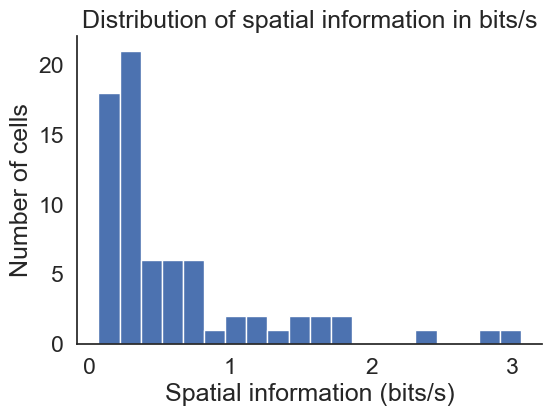

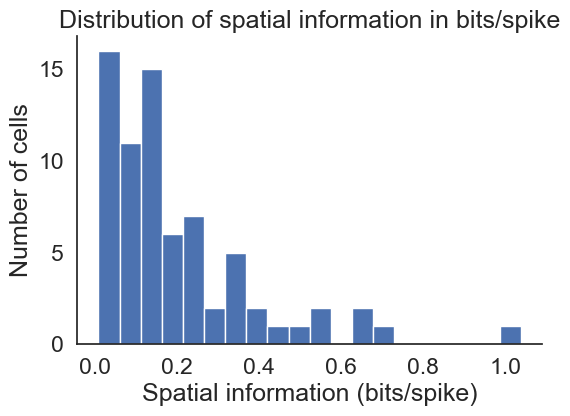

In [18]:
# Plot the distributions of spatial information in bits/s and bits/spike

plt.figure(figsize=(6, 4))
plt.hist(info, bins=20)
plt.xlabel("Spatial information (bits/s)")
plt.ylabel("Number of cells")
plt.title("Distribution of spatial information in bits/s")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(info_per_spike, bins=20)
plt.xlabel("Spatial information (bits/spike)")
plt.ylabel("Number of cells")
plt.title("Distribution of spatial information in bits/spike")
plt.show()

In [ ]:
# make arrays of the fire rate maps in which the cells are sorted form low to to high spatial information
# for both types of information
info = np.array(info)
info_per_spike = np.array(info_per_spike)

idx_info = np.argsort(info)
idx_per_spike = np.argsort(info_per_spike)

maps_sorted = firing_rate_maps[idx_info]
maps_sorted_per_spike = firing_rate_maps[idx_per_spike]



Text(0.5, 1.0, 'fire rate maps of 5 cells with the lowest spatial information (bits/s)')

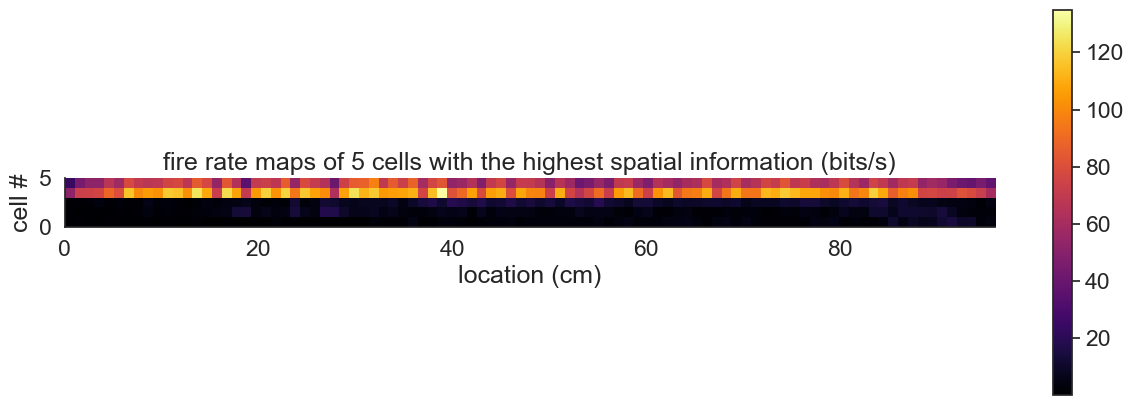

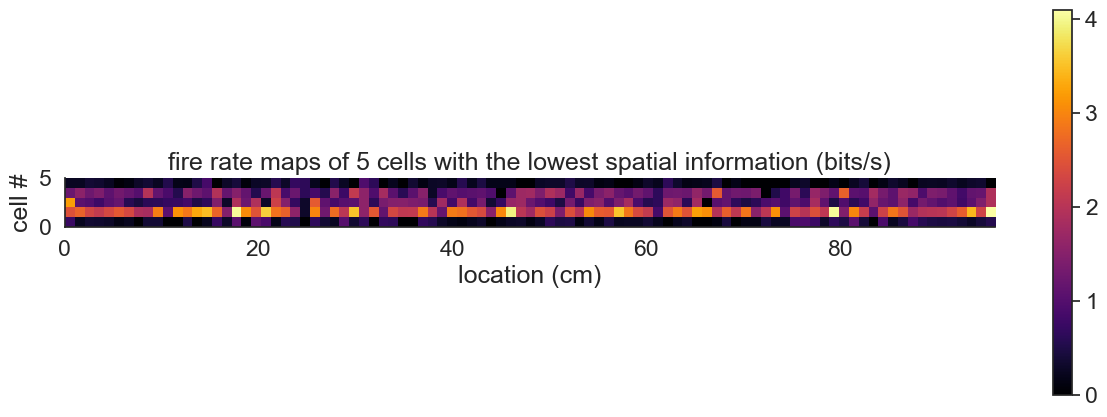

In [ ]:
# See the cell under the 4 plots for my comments

# scatter plots for the fire rate maps of the 5 cells with the highest and lowest spatial information
# with information in bit/s
plt.figure(figsize=(15,5))
plt.imshow(maps_sorted[-5:], cmap='inferno', extent = [0, 96, 0, 5])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title("fire rate maps of 5 cells with the highest spatial information (bits/s)")

plt.figure(figsize=(15,5))
plt.imshow(maps_sorted[0:5], cmap='inferno', extent = [0, 96, 0, 5])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title("fire rate maps of 5 cells with the lowest spatial information (bits/s)")

Text(0.5, 1.0, 'fire rate maps of 5 cells with the lowest spatial information (bits/spike)')

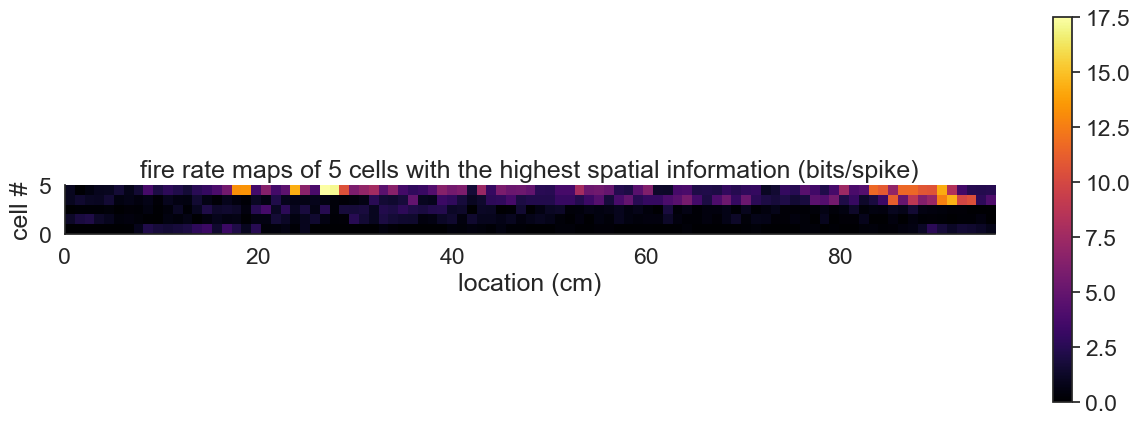

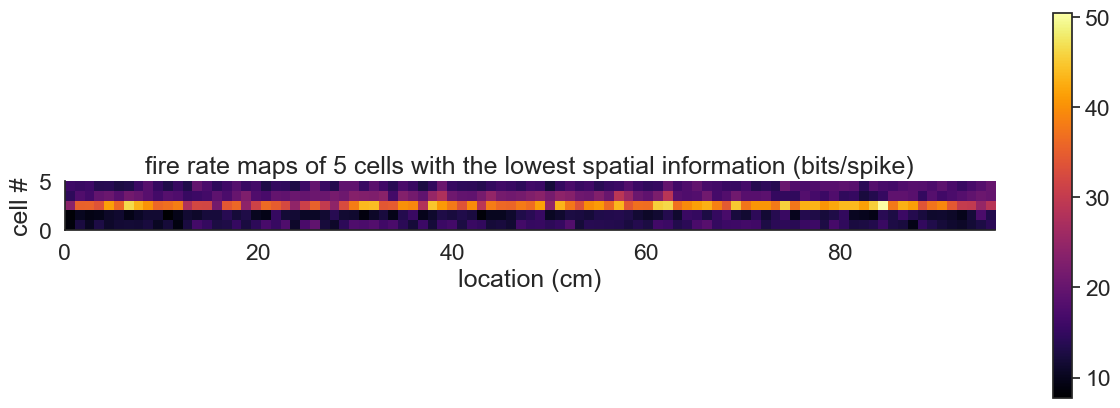

In [ ]:
# See the cell under the 4 plots for my comments

# scatter plots for the fire rate maps of the 5 cells with the highest and lowest spatial information
# with information in bit/sprike

plt.figure(figsize=(15,5))
plt.imshow(maps_sorted_per_spike[-5:], cmap='inferno', extent = [0, 96, 0, 5])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title("fire rate maps of 5 cells with the highest spatial information (bits/spike)")

plt.figure(figsize=(15,5))
plt.imshow(maps_sorted_per_spike[0:5], cmap='inferno', extent = [0, 96, 0, 5])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title("fire rate maps of 5 cells with the lowest spatial information (bits/spike)")

In [ ]:
# For the 5 cells with the highest and lowest spatial information in bits/s its seems
# to depend quite a lot on the mean fire rate of the cells. The fire rate of the 5 cells
# with the highest information is a lot higher than for the 5 lowest information providing cells.
# But not everything depends on it, as the 3 lowest of the 5 highest also have a relative (compared to the two highest)
# a low fire rate. The highest bits/s cells do not necessarily show sharply localized place fields; 
# their high score seems partly driven by high overall firing rates.
# For the plots of the fire rate maps where the cells are sorted based on bits/spike, the ranking seems less strongly influenced 
# by the overall firing rate of the cells, because some cells with low information per spike still have higher firing rates
# than some cells with high information per spike. 
# This could be due to that they are broadly firing cells (maybe interneurons), and fire everywhere and are not (very) spatially dependend.
# Therefore, each spike provides relatively little information about position. Futhermore in the fire rate maps of the top two
# of the 5 highest info providing cells, you can see a clear place field in which their firing rate is higher,
# than for the other spatial positions